# Leakage-Safe, Coverage-Aware Phishing URL Robustness Study

This notebook replaces the earlier row-wise experiment with a reviewer-ready
pipeline. It:

- cleans exact duplicates and removes contradictory duplicate labels;
- builds a canonical URL hash **only for auditing/deduplication** while keeping
  the sanitized original string as model input;
- assigns all URLs from the same registrable domain to one split using a
  stratified five-fold group split (three train folds, one validation fold,
  one test fold);
- fits every learned preprocessing object on the training split only;
- tunes decision thresholds on validation data only and freezes them before
  test evaluation;
- trains deep models over multiple seeds and includes linear, tree, and CharCNN
  baselines;
- saves per-example paired predictions for clean and transformed URLs;
- reports full-test and changed-only paired metrics, conditional and
  unconditional ASR, truncation diagnostics, row-paired and domain-clustered
  uncertainty, McNemar discordant counts, and cluster sign-flip tests;
- exports publication-ready figures, tables, split manifests, configuration,
  and environment metadata.
- writes crash-safe per-run artifacts and restores completed model/seed runs
  from `DONE.json` markers when `/kaggle/working` is still available;
- creates a final ZIP containing models, paired predictions, exact tables,
  figures, checksums, and reproducibility metadata.

**Important:** the corrected split changes the experiment. Previous headline
scores must not be reused. Run `Restart & Run All` on Kaggle with the dataset
attached and a GPU accelerator. A rigorous design can address reviewer
concerns, but no notebook can guarantee a particular score or acceptance.

**Kaggle persistence rule:** `/kaggle/working` survives ordinary cells but is
not durable across every new session. When the final cell prints
`FINAL BACKUP`, download that ZIP immediately or click **Save Version** with
output files enabled. The notebook can resume only from files that still exist.


In [1]:
# 1. Configuration -- edit only this cell when moving between environments.
import os
from pathlib import Path

PRIMARY_SEED = 42
SEEDS = [42, 52, 62]

# These variables are set before TensorFlow is imported in the next cell.
os.environ["PYTHONHASHSEED"] = str(PRIMARY_SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

DATASET_CANDIDATES = [
    "/kaggle/input/datasets/harisudhan411/phishing-and-legitimate-urls/new_data_urls.csv",
    "/kaggle/input/phishing-and-legitimate-urls/new_data_urls.csv",
    "new_data_urls.csv",
    "phishing_urls.csv",
]

OUTPUT_DIR = Path("/kaggle/working/phishing_robustness_v3")
if not Path("/kaggle/working").exists():
    OUTPUT_DIR = Path.cwd() / "phishing_robustness_v3"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "models").mkdir(exist_ok=True)
(OUTPUT_DIR / "predictions").mkdir(exist_ok=True)
(OUTPUT_DIR / "figures").mkdir(exist_ok=True)
(OUTPUT_DIR / "tables").mkdir(exist_ok=True)
(OUTPUT_DIR / "runs").mkdir(exist_ok=True)

# The attached Kaggle dataset uses 0=phishing and 1=legitimate.
RAW_PHISHING_LABEL = 0
RAW_LEGITIMATE_LABEL = 1

N_GROUP_FOLDS = 5               # 3 folds train, 1 validation, 1 test
MAX_URL_LENGTH = 200
EMBEDDING_DIM = 96
MAX_EPOCHS = 15
BATCH_SIZE_GPU = 512
BATCH_SIZE_CPU = 128
EARLY_STOPPING_PATIENCE = 3
THRESHOLD_POLICY = "validation_f1"
PERCENT_ENCODE_RATE = 0.35

RUN_DEEP_MODELS = True
RUN_CLASSICAL_BASELINES = True
RUN_ADAPTIVE_EVALUATION = True
USE_MIXED_PRECISION = True
USE_MULTI_GPU = True
AUTO_RESUME_COMPLETED_RUNS = True
CREATE_FINAL_ZIP = True

# Primary inferential analysis is performed on PRIMARY_SEED. Other seeds
# quantify training variability and are aggregated descriptively.
N_ROW_BOOTSTRAP = 5000
N_CLUSTER_BOOTSTRAP = 1000
N_CLUSTER_SIGN_FLIPS = 5000

CONFIG = {k: v for k, v in globals().copy().items() if k in {
    "PRIMARY_SEED", "SEEDS", "RAW_PHISHING_LABEL", "RAW_LEGITIMATE_LABEL",
    "N_GROUP_FOLDS", "MAX_URL_LENGTH", "EMBEDDING_DIM", "MAX_EPOCHS",
    "EARLY_STOPPING_PATIENCE", "THRESHOLD_POLICY", "PERCENT_ENCODE_RATE",
    "RUN_DEEP_MODELS", "RUN_CLASSICAL_BASELINES", "RUN_ADAPTIVE_EVALUATION",
    "USE_MIXED_PRECISION", "USE_MULTI_GPU", "AUTO_RESUME_COMPLETED_RUNS",
    "CREATE_FINAL_ZIP", "N_ROW_BOOTSTRAP",
    "N_CLUSTER_BOOTSTRAP", "N_CLUSTER_SIGN_FLIPS"
}}
print("Output directory:", OUTPUT_DIR)
print("Configuration:", CONFIG)


Output directory: /kaggle/working/phishing_robustness_v3
Configuration: {'PRIMARY_SEED': 42, 'SEEDS': [42, 52, 62], 'RAW_PHISHING_LABEL': 0, 'RAW_LEGITIMATE_LABEL': 1, 'N_GROUP_FOLDS': 5, 'MAX_URL_LENGTH': 200, 'EMBEDDING_DIM': 96, 'MAX_EPOCHS': 15, 'EARLY_STOPPING_PATIENCE': 3, 'THRESHOLD_POLICY': 'validation_f1', 'PERCENT_ENCODE_RATE': 0.35, 'RUN_DEEP_MODELS': True, 'RUN_CLASSICAL_BASELINES': True, 'RUN_ADAPTIVE_EVALUATION': True, 'USE_MIXED_PRECISION': True, 'USE_MULTI_GPU': True, 'AUTO_RESUME_COMPLETED_RUNS': True, 'CREATE_FINAL_ZIP': True, 'N_ROW_BOOTSTRAP': 5000, 'N_CLUSTER_BOOTSTRAP': 1000, 'N_CLUSTER_SIGN_FLIPS': 5000}


In [2]:
# 2. Imports, versions, and deterministic runtime setup.
import gc
import hashlib
import ipaddress
import json
import math
import platform
import random
import re
import shutil
import subprocess
import sys
import time
import unicodedata
import warnings
from itertools import combinations, permutations
from urllib.parse import SplitResult, urlsplit, urlunsplit

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import seaborn as sns

import sklearn
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    brier_score_loss, confusion_matrix, f1_score, matthews_corrcoef,
    precision_recall_curve, precision_score, recall_score, roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_class_weight

try:
    import tldextract
except ImportError:
    tldextract = None

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import callbacks, layers, models
except ImportError as exc:
    raise ImportError(
        "TensorFlow is required. Run this notebook in Kaggle with a GPU image."
    ) from exc

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="paper", font_scale=1.05)

def set_global_seed(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

def file_sha256(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        while True:
            chunk = handle.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()

set_global_seed(PRIMARY_SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

if gpus and USE_MIXED_PRECISION:
    tf.keras.mixed_precision.set_global_policy("mixed_float16")

if USE_MULTI_GPU and len(gpus) > 1:
    strategy = tf.distribute.MirroredStrategy()
else:
    strategy = tf.distribute.get_strategy()

BATCH_SIZE = BATCH_SIZE_GPU if gpus else BATCH_SIZE_CPU
VERSIONS = {
    "python": platform.python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scipy": scipy.__version__,
    "sklearn": sklearn.__version__,
    "tensorflow": tf.__version__,
}
print(json.dumps(VERSIONS, indent=2))
print(f"GPUs={len(gpus)} | replicas={strategy.num_replicas_in_sync} | batch={BATCH_SIZE}")


INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
{
  "python": "3.12.13",
  "numpy": "2.0.2",
  "pandas": "2.3.3",
  "scipy": "1.16.3",
  "sklearn": "1.6.1",
  "tensorflow": "2.20.0"
}
GPUs=2 | replicas=2 | batch=512


I0000 00:00:1788027564.187704     157 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788027564.190856     157 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [3]:
# 3. Load and validate the raw dataset. Test labels are used only for splitting
# and final evaluation; they are never used for vocabulary fitting or tuning.
dataset_path = next((Path(p) for p in DATASET_CANDIDATES if Path(p).exists()), None)
if dataset_path is None:
    raise FileNotFoundError(
        "Dataset not found. Attach the Kaggle dataset or update DATASET_CANDIDATES."
    )

raw_df = pd.read_csv(dataset_path, low_memory=False)
dataset_sha256 = file_sha256(dataset_path)
raw_df.columns = [str(c).strip().lower() for c in raw_df.columns]

if "url" not in raw_df.columns:
    candidates = [c for c in raw_df.columns if "url" in c]
    if len(candidates) == 1:
        raw_df = raw_df.rename(columns={candidates[0]: "url"})
if "status" not in raw_df.columns:
    candidates = [c for c in raw_df.columns if c in {"label", "class", "target"}]
    if len(candidates) == 1:
        raw_df = raw_df.rename(columns={candidates[0]: "status"})

required = {"url", "status"}
if not required.issubset(raw_df.columns):
    raise ValueError(f"Required columns {required}; found {raw_df.columns.tolist()}")

raw_df = raw_df[["url", "status"]].copy()
raw_df["source_row"] = np.arange(len(raw_df), dtype=np.int64)
print("Dataset:", dataset_path)
print("Dataset SHA-256:", dataset_sha256)
print("Raw shape:", raw_df.shape)
print("Raw labels:")
print(raw_df["status"].value_counts(dropna=False))


Dataset: /kaggle/input/datasets/harisudhan411/phishing-and-legitimate-urls/new_data_urls.csv
Dataset SHA-256: 330901bb4fbb63ffc25d371cf0bed919c1ca031ea1c809bfc9a154a2d79e4a29
Raw shape: (822010, 3)
Raw labels:
status
1    427028
0    394982
Name: count, dtype: int64


## Cleaning and leakage-control policy

The model input retains the sanitized original URL. Canonicalization is used
only to identify exact-equivalent duplicates and to construct split groups.
Rows with the same canonical hash but conflicting labels are removed entirely;
same-label duplicates retain one deterministic representative. Registrable
domains are assigned wholly to one split. URLs without a parseable host receive
their own hash-based group instead of being pooled into a single artificial
group.


In [4]:
# 4. URL cleaning, canonical duplicate keys, and registrable-domain groups.
CONTROL_CHARS = re.compile(r"[\x00-\x1f\x7f]")
SCHEME_RE = re.compile(r"^[A-Za-z][A-Za-z0-9+.-]*://")
COMMON_SECOND_LEVEL_SUFFIXES = {
    "co.uk", "org.uk", "ac.uk", "gov.uk", "com.au", "net.au", "org.au",
    "co.jp", "co.in", "com.br", "com.cn", "com.sg", "com.my", "co.nz",
    "com.mx", "co.za", "com.tr", "com.sa", "com.ar", "com.tw",
}
OFFLINE_TLD = tldextract.TLDExtract(suffix_list_urls=None) if tldextract else None

def clean_url_text(value):
    if pd.isna(value):
        return ""
    value = unicodedata.normalize("NFC", str(value)).strip()
    return CONTROL_CHARS.sub("", value)

def safe_urlsplit(url):
    text = clean_url_text(url)
    has_scheme = bool(SCHEME_RE.match(text))
    target = text if has_scheme else "//" + text
    try:
        parts = urlsplit(target, allow_fragments=True)
    except Exception:
        parts = SplitResult("", "", text, "", "")
    return parts, has_scheme

def safe_hostname(parts):
    try:
        return (parts.hostname or "").strip(".").lower()
    except ValueError:
        return ""

def safe_port(parts):
    try:
        return parts.port
    except ValueError:
        return None

def canonical_url_for_audit(url):
    parts, has_scheme = safe_urlsplit(url)
    host = safe_hostname(parts)
    scheme = parts.scheme.lower()
    port = safe_port(parts)
    if (scheme, port) in {("http", 80), ("https", 443)}:
        port = None
    host_port = host + (f":{port}" if port else "")
    path = re.sub(r"/{2,}", "/", parts.path or "/")
    if path != "/":
        path = path.rstrip("/")
    # Fragments are client-side and are excluded from the duplicate key.
    canonical = urlunsplit((scheme if has_scheme else "", host_port, path, parts.query, ""))
    if not has_scheme and canonical.startswith("//"):
        canonical = canonical[2:]
    return canonical

def sha256_text(value):
    return hashlib.sha256(value.encode("utf-8", errors="replace")).hexdigest()

def registrable_domain(host):
    host = (host or "").strip(".").lower()
    if not host:
        return ""
    try:
        ipaddress.ip_address(host)
        return host
    except ValueError:
        pass
    if OFFLINE_TLD is not None:
        ext = OFFLINE_TLD(host)
        if ext.domain and ext.suffix:
            return f"{ext.domain}.{ext.suffix}".lower()
    labels = [x for x in host.split(".") if x]
    if len(labels) <= 2:
        return host
    suffix2 = ".".join(labels[-2:])
    if suffix2 in COMMON_SECOND_LEVEL_SUFFIXES and len(labels) >= 3:
        return ".".join(labels[-3:])
    return suffix2

def map_label(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().lower()
    phishing_tokens = {
        str(RAW_PHISHING_LABEL).lower(), f"{float(RAW_PHISHING_LABEL):.1f}",
        "phishing", "phish", "malicious",
    }
    legitimate_tokens = {
        str(RAW_LEGITIMATE_LABEL).lower(), f"{float(RAW_LEGITIMATE_LABEL):.1f}",
        "legitimate", "benign", "safe",
    }
    if text in phishing_tokens:
        return 1  # phishing is positive throughout this notebook
    if text in legitimate_tokens:
        return 0
    return np.nan

clean_df = raw_df.copy()
audit = [{"stage": "Raw rows", "rows": len(clean_df)}]

clean_df["url"] = clean_df["url"].map(clean_url_text)
clean_df["y"] = clean_df["status"].map(map_label)
clean_df = clean_df[(clean_df["url"].str.len() > 0) & clean_df["y"].notna()].copy()
clean_df["y"] = clean_df["y"].astype(np.int8)
audit.append({"stage": "Valid URL and label", "rows": len(clean_df)})

clean_df["canonical_url"] = clean_df["url"].map(canonical_url_for_audit)
clean_df["url_hash"] = clean_df["canonical_url"].map(sha256_text)
label_counts = clean_df.groupby("url_hash", observed=True)["y"].nunique()
conflicting_hashes = set(label_counts[label_counts > 1].index)
clean_df = clean_df[~clean_df["url_hash"].isin(conflicting_hashes)].copy()
audit.append({"stage": "Remove contradictory duplicate labels", "rows": len(clean_df)})

clean_df = (
    clean_df.sort_values("source_row")
    .drop_duplicates("url_hash", keep="first")
    .reset_index(drop=True)
)
audit.append({"stage": "Deduplicate canonical URLs", "rows": len(clean_df)})

parsed = clean_df["url"].map(safe_urlsplit)
clean_df["host"] = parsed.map(lambda item: safe_hostname(item[0]))
clean_df["registrable_domain"] = clean_df["host"].map(registrable_domain)
clean_df["domain_group"] = np.where(
    clean_df["registrable_domain"].str.len() > 0,
    clean_df["registrable_domain"],
    "__nohost__:" + clean_df["url_hash"],
)

audit_df = pd.DataFrame(audit)
audit_df["removed_from_previous"] = -audit_df["rows"].diff().fillna(0).astype(int)
print(audit_df.to_string(index=False))
print("\nClean class distribution (1=phishing):")
print(clean_df["y"].value_counts().sort_index())
print("Unique split groups:", clean_df["domain_group"].nunique())
print("Contradictory canonical URLs removed:", len(conflicting_hashes))

del clean_df["canonical_url"]
gc.collect()


                                stage   rows  removed_from_previous
                             Raw rows 822010                      0
                  Valid URL and label 822010                      0
Remove contradictory duplicate labels 821986                     24
           Deduplicate canonical URLs 799620                  22366

Clean class distribution (1=phishing):
y
0    426988
1    372632
Name: count, dtype: int64
Unique split groups: 316685
Contradictory canonical URLs removed: 12


0

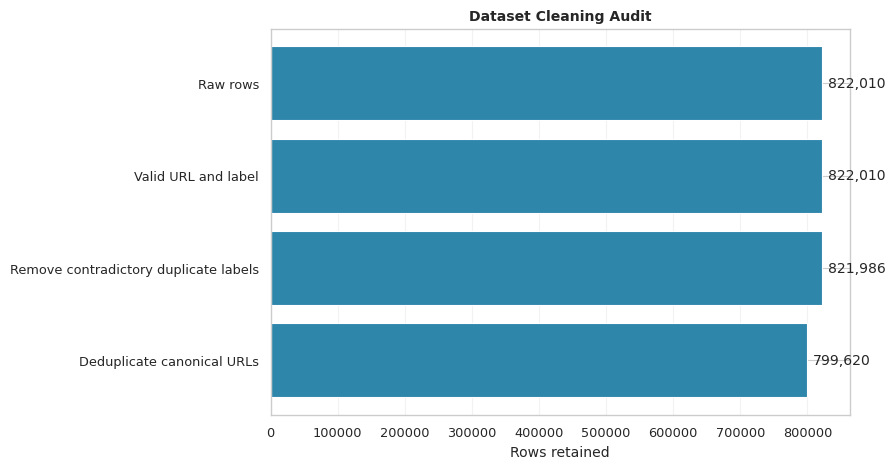

In [5]:
# 5. Cleaning audit visualization.
fig, ax = plt.subplots(figsize=(9, 4.8))
bars = ax.barh(audit_df["stage"], audit_df["rows"], color="#2E86AB")
ax.bar_label(bars, labels=[f"{x:,}" for x in audit_df["rows"]], padding=4)
ax.invert_yaxis()
ax.set_xlabel("Rows retained")
ax.set_title("Dataset Cleaning Audit", fontweight="bold")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figures/FIG00_Cleaning_Audit.png", dpi=300, bbox_inches="tight")
plt.show()


In [6]:
# 6. Five-fold stratified group assignment and deterministic 60/20/20 selection.
# All rows in a domain_group remain in exactly one fold.
sgkf = StratifiedGroupKFold(
    n_splits=N_GROUP_FOLDS, shuffle=True, random_state=PRIMARY_SEED
)
fold_id = np.full(len(clean_df), -1, dtype=np.int8)
dummy_x = np.zeros((len(clean_df), 1), dtype=np.int8)
for fold, (_, held_out) in enumerate(
    sgkf.split(dummy_x, clean_df["y"].to_numpy(), clean_df["domain_group"].to_numpy())
):
    fold_id[held_out] = fold
assert np.all(fold_id >= 0)
clean_df["fold"] = fold_id

global_prev = clean_df["y"].mean()
target = {"train": 0.60, "validation": 0.20, "test": 0.20}
candidate_assignments = []
for test_fold, val_fold in permutations(range(N_GROUP_FOLDS), 2):
    split = np.where(
        fold_id == test_fold, "test",
        np.where(fold_id == val_fold, "validation", "train")
    )
    score = 0.0
    details = {}
    for name in ["train", "validation", "test"]:
        mask = split == name
        fraction = mask.mean()
        prevalence = clean_df.loc[mask, "y"].mean()
        score += abs(fraction - target[name]) / target[name]
        score += 2.0 * abs(prevalence - global_prev)
        details[f"{name}_fraction"] = fraction
        details[f"{name}_prevalence"] = prevalence
    candidate_assignments.append((score, test_fold, val_fold, split, details))

candidate_assignments.sort(key=lambda x: (x[0], x[1], x[2]))
split_score, test_fold, val_fold, split_values, split_details = candidate_assignments[0]
clean_df["split"] = pd.Categorical(
    split_values, categories=["train", "validation", "test"], ordered=True
)

def assert_no_overlap(frame, key):
    sets = {
        name: set(frame.loc[frame["split"] == name, key])
        for name in ["train", "validation", "test"]
    }
    for left, right in [("train", "validation"), ("train", "test"), ("validation", "test")]:
        overlap = sets[left] & sets[right]
        assert not overlap, f"Leakage detected in {key}: {left}/{right} share {len(overlap)} values"

assert_no_overlap(clean_df, "url_hash")
assert_no_overlap(clean_df, "domain_group")
assert clean_df["url_hash"].is_unique

split_summary = (
    clean_df.groupby("split", observed=False)
    .agg(rows=("y", "size"), phishing=("y", "sum"), groups=("domain_group", "nunique"))
    .reset_index()
)
split_summary["legitimate"] = split_summary["rows"] - split_summary["phishing"]
split_summary["row_share"] = split_summary["rows"] / len(clean_df)
split_summary["phishing_prevalence"] = split_summary["phishing"] / split_summary["rows"]

print(f"Selected validation fold={val_fold}, test fold={test_fold}, score={split_score:.6f}")
print(split_summary.to_string(index=False))
print("\nLeakage checks passed:")
print("  canonical URL overlap: 0")
print("  registrable-domain overlap: 0")

train_df = clean_df[clean_df["split"] == "train"].reset_index(drop=True)
val_df = clean_df[clean_df["split"] == "validation"].reset_index(drop=True)
test_df = clean_df[clean_df["split"] == "test"].reset_index(drop=True)

manifest = clean_df[["source_row", "url_hash", "domain_group", "y", "fold", "split"]].copy()
manifest.to_csv(OUTPUT_DIR / "tables/SPLIT_MANIFEST.csv.gz", index=False, compression="gzip")
audit_df.to_csv(OUTPUT_DIR / "tables/CLEANING_AUDIT.csv", index=False)
split_summary.to_csv(OUTPUT_DIR / "tables/SPLIT_SUMMARY.csv", index=False)


Selected validation fold=0, test fold=1, score=0.252304
     split   rows  phishing  groups  legitimate  row_share  phishing_prevalence
     train 471429    230802  190019      240627   0.589566             0.489580
validation 162900     69320   63340       93580   0.203722             0.425537
      test 165291     72510   63326       92781   0.206712             0.438681

Leakage checks passed:
  canonical URL overlap: 0
  registrable-domain overlap: 0


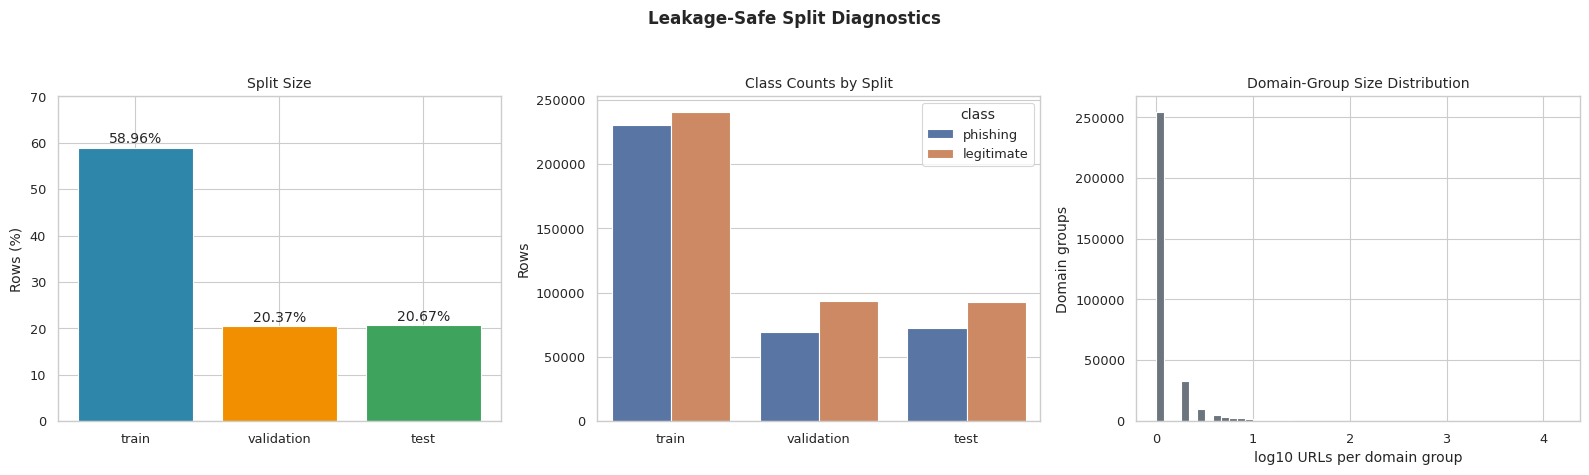

In [7]:
# 7. Split diagnostics. The zero-overlap panel is an executable assertion,
# not merely a claim in the manuscript.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

plot_split = split_summary.copy()
axes[0].bar(plot_split["split"], 100 * plot_split["row_share"], color=["#2E86AB", "#F18F01", "#3DA35D"])
axes[0].set_ylabel("Rows (%)")
axes[0].set_title("Split Size")
axes[0].set_ylim(0, 70)
for i, value in enumerate(100 * plot_split["row_share"]):
    axes[0].text(i, value + 1, f"{value:.2f}%", ha="center")

class_long = plot_split.melt(
    id_vars="split", value_vars=["phishing", "legitimate"],
    var_name="class", value_name="count"
)
sns.barplot(data=class_long, x="split", y="count", hue="class", ax=axes[1])
axes[1].set_title("Class Counts by Split")
axes[1].set_xlabel("")
axes[1].set_ylabel("Rows")

group_sizes = clean_df.groupby("domain_group", observed=True).size()
axes[2].hist(np.log10(group_sizes), bins=50, color="#6C757D")
axes[2].set_xlabel("log10 URLs per domain group")
axes[2].set_ylabel("Domain groups")
axes[2].set_title("Domain-Group Size Distribution")

fig.suptitle("Leakage-Safe Split Diagnostics", fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(OUTPUT_DIR / "figures/FIG01_Split_Diagnostics.png", dpi=300, bbox_inches="tight")
plt.show()


## Training-only character vocabulary

The earlier notebook constructed its vocabulary from the complete dataset.
Here `TextVectorization.adapt` sees training URLs only. Validation and test
characters absent from training map to the OOV index. The layer is then frozen
and reused by every deep architecture and every seed.


In [8]:
# 8. Fit the character vectorizer on training URLs only.
vectorizer = layers.TextVectorization(
    standardize=None,
    split="character",
    output_mode="int",
    output_sequence_length=MAX_URL_LENGTH,
)
train_text_for_adapt = tf.data.Dataset.from_tensor_slices(
    train_df["url"].astype(str).to_numpy()
).batch(8192)
vectorizer.adapt(train_text_for_adapt)
vectorizer.trainable = False

CHAR_VOCAB = vectorizer.get_vocabulary()
VOCAB_SIZE = len(CHAR_VOCAB)
assert CHAR_VOCAB[0] == ""       # padding index
assert CHAR_VOCAB[1] == "[UNK]"  # OOV index

(OUTPUT_DIR / "character_vocabulary.json").write_text(
    json.dumps(CHAR_VOCAB, ensure_ascii=False, indent=2), encoding="utf-8"
)
print(f"Training-only character vocabulary: {VOCAB_SIZE} tokens")
print(f"Train URLs={len(train_df):,}; validation={len(val_df):,}; test={len(test_df):,}")


Training-only character vocabulary: 253 tokens
Train URLs=471,429; validation=162,900; test=165,291


## Standards-aware representation transformations

The primary transformation percent-encodes a deterministic subset of ASCII
unreserved characters in path and query keys/values while preserving structural
delimiters (`/`, `?`, `&`, `=`). Additional controls vary DNS host case, add
the scheme's default port, or convert eligible internationalized hosts to IDNA.
Coverage is measured for every transformation; unchanged URLs are never passed
off as attacked examples. An optional fixed-budget black-box evaluation chooses
the lowest phishing probability among the clean URL and all generated variants.

These are representation tests, not proof that every server processes every
variant identically. Destination equivalence is therefore not claimed.


In [9]:
# 9. Deterministic, parser-based transformations and unit tests.
ASCII_UNRESERVED = set("ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789-._~")

def rebuild_url(parts, had_scheme, *, netloc=None, path=None, query=None):
    rebuilt = urlunsplit((
        parts.scheme,
        parts.netloc if netloc is None else netloc,
        parts.path if path is None else path,
        parts.query if query is None else query,
        parts.fragment,
    ))
    if not had_scheme and rebuilt.startswith("//"):
        rebuilt = rebuilt[2:]
    return rebuilt

def deterministic_percent_encode(text, salt, rate=PERCENT_ENCODE_RATE):
    eligible = [i for i, char in enumerate(text) if char in ASCII_UNRESERVED]
    selected = []
    for i in eligible:
        digest = hashlib.sha256(f"{salt}|{i}|{text[i]}".encode()).digest()
        if int.from_bytes(digest[:2], "big") / 65535.0 < rate:
            selected.append(i)
    if eligible and not selected:
        selected = [eligible[0]]
    selected = set(selected)
    out = []
    for i, char in enumerate(text):
        if i in selected:
            out.extend(f"%{byte:02X}" for byte in char.encode("ascii"))
        else:
            out.append(char)
    return "".join(out)

def transform_percent_path_query(url):
    parts, had_scheme = safe_urlsplit(url)
    salt = sha256_text(clean_url_text(url))[:16]
    new_path = deterministic_percent_encode(parts.path, salt + "|path")
    query_chunks = []
    for chunk_index, chunk in enumerate(re.split(r"([&;])", parts.query)):
        if chunk in {"&", ";"}:
            query_chunks.append(chunk)
            continue
        key, separator, value = chunk.partition("=")
        key = deterministic_percent_encode(key, f"{salt}|qk|{chunk_index}")
        value = deterministic_percent_encode(value, f"{salt}|qv|{chunk_index}")
        query_chunks.append(key + separator + value)
    new_query = "".join(query_chunks)
    return rebuild_url(parts, had_scheme, path=new_path, query=new_query)

def replace_host_in_netloc(parts, new_host, new_port=None):
    netloc = parts.netloc
    userinfo = ""
    if "@" in netloc:
        userinfo, _ = netloc.rsplit("@", 1)
        userinfo += "@"
    host_display = f"[{new_host}]" if ":" in new_host and not new_host.startswith("[") else new_host
    port = safe_port(parts) if new_port is None else new_port
    return userinfo + host_display + (f":{port}" if port is not None else "")

def transform_host_case(url):
    parts, had_scheme = safe_urlsplit(url)
    host = safe_hostname(parts)
    if not host or not any(c.isalpha() for c in host):
        return clean_url_text(url)
    new_netloc = replace_host_in_netloc(parts, host.upper())
    return rebuild_url(parts, had_scheme, netloc=new_netloc)

def transform_default_port(url):
    parts, had_scheme = safe_urlsplit(url)
    host = safe_hostname(parts)
    if not had_scheme or not host or safe_port(parts) is not None:
        return clean_url_text(url)
    default_port = {"http": 80, "https": 443}.get(parts.scheme.lower())
    if default_port is None:
        return clean_url_text(url)
    return rebuild_url(parts, had_scheme, netloc=replace_host_in_netloc(parts, host, default_port))

def transform_idna_host(url):
    parts, had_scheme = safe_urlsplit(url)
    host = safe_hostname(parts)
    if not host or host.isascii():
        return clean_url_text(url)
    try:
        encoded = host.encode("idna").decode("ascii")
    except UnicodeError:
        return clean_url_text(url)
    return rebuild_url(parts, had_scheme, netloc=replace_host_in_netloc(parts, encoded))

TRANSFORMATIONS = {
    "percent_path_query": transform_percent_path_query,
    "host_case_control": transform_host_case,
    "default_port_control": transform_default_port,
    "idna_host": transform_idna_host,
}

# Small deterministic unit tests. They fail loudly before any model training.
example = "https://Example.com/login/account?id=123&next=home"
variant = transform_percent_path_query(example)
assert variant == transform_percent_path_query(example)
assert "https://Example.com/" in variant
assert "?" in variant and "&" in variant and "=" in variant
assert transform_host_case(example).startswith("https://EXAMPLE.COM/")
assert ":443" in transform_default_port(example)
assert transform_idna_host("https://münich.example/path").startswith("https://xn--")
print("Transformation unit tests passed.")


Transformation unit tests passed.


In [10]:
# 10. Generate paired test conditions and audit actual transformation coverage.
test_urls_clean = test_df["url"].fillna("").astype(str).to_numpy()
y_test = test_df["y"].to_numpy(dtype=np.int8)
test_groups = test_df["domain_group"].fillna("").astype(str).to_numpy()

def string_lengths(values):
    """Safe string lengths for NumPy object, Unicode, or pandas-backed arrays."""
    values = np.asarray(values).reshape(-1)
    return np.fromiter(
        (len(str(value)) for value in values),
        dtype=np.int32,
        count=values.size,
    )

clean_lengths = string_lengths(test_urls_clean)
clean_over_limit = clean_lengths > MAX_URL_LENGTH

condition_urls = {"clean": test_urls_clean}
changed_masks = {"clean": np.zeros(len(test_df), dtype=bool)}
transform_audit_rows = []

for condition, function in TRANSFORMATIONS.items():
    urls = np.asarray([str(function(url)) for url in test_urls_clean], dtype=object)
    changed = urls != test_urls_clean
    transformed_lengths = string_lengths(urls)
    transformed_over_limit = transformed_lengths > MAX_URL_LENGTH
    newly_over_limit = (~clean_over_limit) & transformed_over_limit
    condition_urls[condition] = urls
    changed_masks[condition] = changed
    transform_audit_rows.append({
        "condition": condition,
        "rows": len(urls),
        "changed": int(changed.sum()),
        "coverage": float(changed.mean()),
        "changed_phishing": int(np.sum(changed & (y_test == 1))),
        "changed_legitimate": int(np.sum(changed & (y_test == 0))),
        "over_limit_clean": int(clean_over_limit.sum()),
        "over_limit_transformed": int(transformed_over_limit.sum()),
        "newly_over_limit": int(newly_over_limit.sum()),
    })

transform_audit_df = pd.DataFrame(transform_audit_rows)
transform_audit_df.to_csv(OUTPUT_DIR / "tables/TRANSFORMATION_AUDIT.csv", index=False)
print(transform_audit_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


           condition   rows  changed  coverage  changed_phishing  changed_legitimate  over_limit_clean  over_limit_transformed  newly_over_limit
  percent_path_query 165291   114034    0.6899             34864               79170              3355                    5809              2454
   host_case_control 165291   163848    0.9913             71078               92770              3355                    3355                 0
default_port_control 165291    37647    0.2278             29910                7737              3355                    3362                 7
           idna_host 165291        4    0.0000                 1                   3              3355                    3355                 0


## Metrics and inference

Phishing is positive (`1`) everywhere below. Thresholds are selected on clean
validation probabilities and then frozen. For each transformation, the notebook
reports metrics on the full test set and on the exact changed subset before and
after transformation. ASR is reported both unconditionally and conditionally
on URLs that actually changed. Row-paired bootstrap intervals are supplemented
with a registrable-domain cluster bootstrap. Row-level McNemar counts are shown
as a familiar secondary test; a domain-cluster sign-flip test is the primary
dependence-aware paired significance check.


In [11]:
# 11. Metric, threshold, paired-test, multiplicity, and calibration utilities.
def choose_threshold(y_true, probability, policy=THRESHOLD_POLICY):
    if policy == "fixed_0.5":
        return 0.5
    precision, recall, thresholds = precision_recall_curve(y_true, probability)
    if len(thresholds) == 0:
        return 0.5
    f1 = 2 * precision[:-1] * recall[:-1] / np.maximum(precision[:-1] + recall[:-1], 1e-12)
    return float(thresholds[int(np.nanargmax(f1))])

def expected_calibration_error(y_true, probability, bins=15):
    edges = np.linspace(0, 1, bins + 1)
    ids = np.clip(np.digitize(probability, edges[1:-1]), 0, bins - 1)
    ece = 0.0
    for bin_id in range(bins):
        mask = ids == bin_id
        if np.any(mask):
            ece += mask.mean() * abs(y_true[mask].mean() - probability[mask].mean())
    return float(ece)

def binary_metrics(y_true, probability, threshold):
    y_true = np.asarray(y_true, dtype=np.int8)
    probability = np.asarray(probability, dtype=float)
    pred = (probability >= threshold).astype(np.int8)
    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return {
        "n": int(len(y_true)),
        "prevalence": float(y_true.mean()),
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "specificity": tn / max(tn + fp, 1),
        "f1": f1_score(y_true, pred, zero_division=0),
        "pr_auc": average_precision_score(y_true, probability),
        "roc_auc": roc_auc_score(y_true, probability) if len(np.unique(y_true)) == 2 else np.nan,
        "mcc": matthews_corrcoef(y_true, pred),
        "brier": brier_score_loss(y_true, probability),
        "ece_15": expected_calibration_error(y_true, probability, bins=15),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

def wilson_interval(successes, trials, confidence=0.95):
    if trials == 0:
        return np.nan, np.nan
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    p = successes / trials
    denominator = 1 + z * z / trials
    center = (p + z * z / (2 * trials)) / denominator
    margin = z * math.sqrt(p * (1 - p) / trials + z * z / (4 * trials * trials)) / denominator
    return center - margin, center + margin

def holm_adjust(p_values):
    p = np.asarray(p_values, dtype=float)
    order = np.argsort(p)
    adjusted = np.empty_like(p)
    running = 0.0
    m = len(p)
    for rank, index in enumerate(order):
        value = min(1.0, (m - rank) * p[index])
        running = max(running, value)
        adjusted[index] = running
    return adjusted

def f1_from_joint_counts(counts, prediction_bit):
    code = np.arange(8)
    y_bit = (code // 4) == 1
    if prediction_bit == "clean":
        pred_bit = ((code // 2) % 2) == 1
    else:
        pred_bit = (code % 2) == 1
    tp = counts[..., y_bit & pred_bit].sum(axis=-1)
    fp = counts[..., (~y_bit) & pred_bit].sum(axis=-1)
    fn = counts[..., y_bit & (~pred_bit)].sum(axis=-1)
    denominator = 2 * tp + fp + fn
    return np.divide(2 * tp, denominator, out=np.zeros_like(tp, dtype=float), where=denominator != 0)

def paired_row_bootstrap_f1_drop(y, pred_clean, pred_changed, mask=None, n_boot=N_ROW_BOOTSTRAP, seed=PRIMARY_SEED):
    y = np.asarray(y, dtype=np.int8)
    pred_clean = np.asarray(pred_clean, dtype=np.int8)
    pred_changed = np.asarray(pred_changed, dtype=np.int8)
    if mask is None:
        mask = np.ones(len(y), dtype=bool)
    codes = y[mask] * 4 + pred_clean[mask] * 2 + pred_changed[mask]
    frequencies = np.bincount(codes, minlength=8)
    rng = np.random.default_rng(seed)
    samples = rng.multinomial(len(codes), frequencies / frequencies.sum(), size=n_boot)
    drops = f1_from_joint_counts(samples, "clean") - f1_from_joint_counts(samples, "changed")
    return float(drops.mean()), float(np.percentile(drops, 2.5)), float(np.percentile(drops, 97.5))

def domain_joint_counts(y, pred_clean, pred_changed, groups, mask):
    group_codes, uniques = pd.factorize(np.asarray(groups)[mask], sort=False)
    codes = np.asarray(y)[mask] * 4 + np.asarray(pred_clean)[mask] * 2 + np.asarray(pred_changed)[mask]
    matrix = np.zeros((len(uniques), 8), dtype=np.int32)
    np.add.at(matrix, (group_codes, codes), 1)
    return matrix

def paired_cluster_bootstrap_f1_drop(y, pred_clean, pred_changed, groups, mask=None,
                                     n_boot=N_CLUSTER_BOOTSTRAP, seed=PRIMARY_SEED, batch=25):
    if mask is None:
        mask = np.ones(len(y), dtype=bool)
    cluster_counts = domain_joint_counts(y, pred_clean, pred_changed, groups, mask)
    rng = np.random.default_rng(seed)
    drops = []
    for start in range(0, n_boot, batch):
        size = min(batch, n_boot - start)
        weights = rng.poisson(1.0, size=(size, len(cluster_counts))).astype(np.int16)
        counts = weights @ cluster_counts
        drops.extend((f1_from_joint_counts(counts, "clean") - f1_from_joint_counts(counts, "changed")).tolist())
    drops = np.asarray(drops)
    return float(drops.mean()), float(np.percentile(drops, 2.5)), float(np.percentile(drops, 97.5))

def mcnemar_test(y, pred_clean, pred_changed, mask=None):
    if mask is None:
        mask = np.ones(len(y), dtype=bool)
    correct_clean = np.asarray(pred_clean)[mask] == np.asarray(y)[mask]
    correct_changed = np.asarray(pred_changed)[mask] == np.asarray(y)[mask]
    b = int(np.sum(correct_clean & ~correct_changed))
    c = int(np.sum(~correct_clean & correct_changed))
    if b + c == 0:
        return b, c, 0.0, 1.0
    if b + c < 25:
        p_value = stats.binomtest(min(b, c), b + c, 0.5, alternative="two-sided").pvalue
        statistic = np.nan
    else:
        statistic = (abs(b - c) - 1) ** 2 / (b + c)
        p_value = stats.chi2.sf(statistic, 1)
    return b, c, float(statistic), float(p_value)

def cluster_sign_flip_test(y, pred_clean, pred_changed, groups, mask=None,
                           n_permutations=N_CLUSTER_SIGN_FLIPS, seed=PRIMARY_SEED, batch=100):
    if mask is None:
        mask = np.ones(len(y), dtype=bool)
    group_id, unique_groups = pd.factorize(np.asarray(groups)[mask], sort=False)
    correct_clean = (np.asarray(pred_clean)[mask] == np.asarray(y)[mask]).astype(np.int16)
    correct_changed = (np.asarray(pred_changed)[mask] == np.asarray(y)[mask]).astype(np.int16)
    differences = np.zeros(len(unique_groups), dtype=np.int32)
    np.add.at(differences, group_id, correct_clean - correct_changed)
    observed = abs(differences.sum())
    rng = np.random.default_rng(seed)
    exceed = 0
    completed = 0
    while completed < n_permutations:
        size = min(batch, n_permutations - completed)
        signs = rng.choice(np.array([-1, 1], dtype=np.int8), size=(size, len(differences)))
        permuted = np.abs(signs @ differences)
        exceed += int(np.sum(permuted >= observed))
        completed += size
    return float((exceed + 1) / (n_permutations + 1)), int(len(unique_groups)), int(observed)

print("Statistical utilities ready.")


Statistical utilities ready.


## Comparable deep architectures

The recurrent and attention models use a common training-only vectorizer and
similar parameter budgets. The Transformer includes explicit learned positional
embeddings, padding-aware attention, and padding-aware pooling. A CharCNN is
included as a neural baseline. Exact trainable parameter counts and inference
latency are exported rather than asserted qualitatively.


In [12]:
# 12. Keras 3-compatible, mask-aware numeric-token model factories.
# TextVectorization runs in the tf.data input pipeline (cell 13), so distributed
# replicas receive numeric tensors rather than raw tf.string values.
ops = keras.ops

@tf.keras.utils.register_keras_serializable()
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, vocab_size, max_length, embedding_dim, **kwargs):
        super().__init__(**kwargs)
        self.vocab_size = vocab_size
        self.max_length = max_length
        self.embedding_dim = embedding_dim
        self.token_embedding = layers.Embedding(
            vocab_size, embedding_dim, mask_zero=True, name="token_embedding"
        )
        self.position_embedding = layers.Embedding(
            max_length, embedding_dim, name="position_embedding"
        )
        self.supports_masking = True

    def call(self, token_ids):
        length = ops.shape(token_ids)[-1]
        positions = ops.arange(0, length, 1, dtype="int32")
        return self.token_embedding(token_ids) + self.position_embedding(positions)

    def compute_mask(self, token_ids, mask=None):
        return ops.not_equal(token_ids, 0)

    def get_config(self):
        config = super().get_config()
        config.update({
            "vocab_size": self.vocab_size,
            "max_length": self.max_length,
            "embedding_dim": self.embedding_dim,
        })
        return config

@tf.keras.utils.register_keras_serializable()
class TransformerBlock(layers.Layer):
    def __init__(self, embedding_dim, num_heads, ff_dim, dropout=0.2, **kwargs):
        super().__init__(**kwargs)
        self.embedding_dim = embedding_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.dropout_rate = dropout
        self.attention = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embedding_dim // num_heads,
            dropout=dropout,
        )
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="gelu"),
            layers.Dropout(dropout),
            layers.Dense(embedding_dim),
        ])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(dropout)
        self.drop2 = layers.Dropout(dropout)
        self.supports_masking = True

    def call(self, inputs, training=None, mask=None):
        attention_mask = None if mask is None else ops.expand_dims(mask, axis=1)
        attended = self.attention(
            query=inputs,
            value=inputs,
            key=inputs,
            attention_mask=attention_mask,
            training=training,
        )
        x = self.norm1(inputs + self.drop1(attended, training=training))
        projected = self.ffn(x, training=training)
        return self.norm2(x + self.drop2(projected, training=training))

    def compute_mask(self, inputs, mask=None):
        return mask

    def get_config(self):
        config = super().get_config()
        config.update({
            "embedding_dim": self.embedding_dim,
            "num_heads": self.num_heads,
            "ff_dim": self.ff_dim,
            "dropout": self.dropout_rate,
        })
        return config

@tf.keras.utils.register_keras_serializable()
class MaskedGlobalAveragePooling1D(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.supports_masking = True

    def call(self, inputs, mask=None):
        if mask is None:
            return ops.mean(inputs, axis=1)
        weights = ops.expand_dims(ops.cast(mask, inputs.dtype), axis=-1)
        numerator = ops.sum(inputs * weights, axis=1)
        denominator = ops.maximum(
            ops.sum(weights, axis=1), ops.cast(1.0, inputs.dtype)
        )
        return numerator / denominator

    def compute_mask(self, inputs, mask=None):
        return None

def token_input():
    inputs = layers.Input(
        shape=(MAX_URL_LENGTH,), dtype="int64", name="token_ids"
    )
    return inputs, inputs

def build_lstm():
    inputs, tokens = token_input()
    x = layers.Embedding(VOCAB_SIZE, EMBEDDING_DIM, mask_zero=True)(tokens)
    x = layers.LSTM(128, dropout=0.25)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(1, activation="sigmoid", dtype="float32")(x)
    return keras.Model(inputs, outputs, name="LSTM")

def build_bilstm():
    inputs, tokens = token_input()
    x = layers.Embedding(VOCAB_SIZE, EMBEDDING_DIM, mask_zero=True)(tokens)
    x = layers.Bidirectional(layers.LSTM(64, dropout=0.25))(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(1, activation="sigmoid", dtype="float32")(x)
    return keras.Model(inputs, outputs, name="BiLSTM")

def build_charcnn():
    inputs, tokens = token_input()
    x = layers.Embedding(VOCAB_SIZE, EMBEDDING_DIM)(tokens)
    branches = []
    for kernel in [3, 5, 7]:
        branch = layers.Conv1D(64, kernel, activation="relu", padding="same")(x)
        branch = layers.GlobalMaxPooling1D()(branch)
        branches.append(branch)
    x = layers.Concatenate()(branches)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(1, activation="sigmoid", dtype="float32")(x)
    return keras.Model(inputs, outputs, name="CharCNN")

def build_transformer():
    inputs, tokens = token_input()
    x = TokenAndPositionEmbedding(
        VOCAB_SIZE, MAX_URL_LENGTH, EMBEDDING_DIM
    )(tokens)
    x = TransformerBlock(
        EMBEDDING_DIM, num_heads=4, ff_dim=128, dropout=0.20
    )(x)
    x = TransformerBlock(
        EMBEDDING_DIM, num_heads=4, ff_dim=128, dropout=0.20
    )(x)
    x = MaskedGlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(1, activation="sigmoid", dtype="float32")(x)
    return keras.Model(inputs, outputs, name="Transformer")

MODEL_FACTORIES = {
    "LSTM": build_lstm,
    "BiLSTM": build_bilstm,
    "CharCNN": build_charcnn,
    "Transformer": build_transformer,
}
MODEL_LEARNING_RATES = {
    "LSTM": 1e-3, "BiLSTM": 1e-3, "CharCNN": 1e-3, "Transformer": 5e-4
}

with strategy.scope():
    parameter_preview = {name: factory().count_params() for name, factory in MODEL_FACTORIES.items()}
print("Trainable parameter counts:")
print(pd.Series(parameter_preview).to_string())
tf.keras.backend.clear_session()


Trainable parameter counts:
LSTM           147809
BiLSTM         115041
CharCNN        129057
Transformer    174625


In [13]:
# 13. Training and prediction helpers.
train_urls = train_df["url"].astype(str).to_numpy()
y_train = train_df["y"].to_numpy(dtype=np.int8)
val_urls = val_df["url"].astype(str).to_numpy()
y_val = val_df["y"].to_numpy(dtype=np.int8)

classes = np.array([0, 1], dtype=np.int8)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
CLASS_WEIGHT = {int(label): float(weight) for label, weight in zip(classes, weights)}
TRAIN_SAMPLE_WEIGHTS = np.where(y_train == 1, CLASS_WEIGHT[1], CLASS_WEIGHT[0]).astype(np.float32)

def make_tf_dataset(urls, labels=None, training=False, seed=PRIMARY_SEED, sample_weights=None):
    urls = np.asarray([str(value) for value in np.asarray(urls).reshape(-1)], dtype=str)
    if labels is None:
        dataset = tf.data.Dataset.from_tensor_slices(urls)
    elif sample_weights is not None:
        dataset = tf.data.Dataset.from_tensor_slices((
            urls, np.asarray(labels, dtype=np.float32), np.asarray(sample_weights, dtype=np.float32)
        ))
    else:
        dataset = tf.data.Dataset.from_tensor_slices((urls, np.asarray(labels, dtype=np.float32)))
    if training:
        dataset = dataset.shuffle(
            min(len(urls), 200_000), seed=seed, reshuffle_each_iteration=True
        )
    dataset = dataset.batch(BATCH_SIZE, drop_remainder=training)

    # Vectorization is executed in the input pipeline before distribution.
    # This prevents MirroredStrategy from attempting to reduce tf.string state.
    if labels is None:
        dataset = dataset.map(
            lambda batch_urls: tf.cast(vectorizer(batch_urls), tf.int64),
            num_parallel_calls=tf.data.AUTOTUNE,
            deterministic=True,
        )
    elif sample_weights is not None:
        dataset = dataset.map(
            lambda batch_urls, batch_labels, batch_weights: (
                tf.cast(vectorizer(batch_urls), tf.int64),
                batch_labels,
                batch_weights,
            ),
            num_parallel_calls=tf.data.AUTOTUNE,
            deterministic=True,
        )
    else:
        dataset = dataset.map(
            lambda batch_urls, batch_labels: (
                tf.cast(vectorizer(batch_urls), tf.int64),
                batch_labels,
            ),
            num_parallel_calls=tf.data.AUTOTUNE,
            deterministic=True,
        )
    return dataset.prefetch(tf.data.AUTOTUNE)

def predict_probabilities(model, urls):
    dataset = make_tf_dataset(urls, labels=None, training=False)
    _ = model.predict(dataset.take(1), verbose=0)  # warm-up excluded from latency
    start = time.perf_counter()
    probability = model.predict(dataset, verbose=0).reshape(-1).astype(np.float64)
    elapsed = time.perf_counter() - start
    return probability, elapsed, 1000 * elapsed / len(urls)

def train_deep_model(model_name, seed):
    set_global_seed(seed)
    tf.keras.backend.clear_session()
    with strategy.scope():
        model = MODEL_FACTORIES[model_name]()
        optimizer = keras.optimizers.Adam(
            learning_rate=MODEL_LEARNING_RATES[model_name], clipnorm=1.0
        )
        model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])

    checkpoint = OUTPUT_DIR / "models" / f"{model_name}_seed{seed}.weights.h5"
    callback_list = [
        callbacks.EarlyStopping(
            monitor="val_loss", patience=EARLY_STOPPING_PATIENCE,
            min_delta=1e-4, restore_best_weights=True, verbose=1,
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=1, min_lr=1e-6, verbose=1,
        ),
        callbacks.ModelCheckpoint(
            checkpoint, monitor="val_loss", save_best_only=True,
            save_weights_only=True, verbose=0,
        ),
        callbacks.TerminateOnNaN(),
    ]
    start = time.perf_counter()
    history = model.fit(
        make_tf_dataset(
            train_urls, y_train, training=True, seed=seed,
            sample_weights=TRAIN_SAMPLE_WEIGHTS,
        ),
        validation_data=make_tf_dataset(val_urls, y_val, training=False),
        epochs=MAX_EPOCHS,
        callbacks=callback_list,
        verbose=2,
    )
    training_seconds = time.perf_counter() - start
    val_probability, _, _ = predict_probabilities(model, val_urls)
    threshold = choose_threshold(y_val, val_probability)
    return model, history.history, threshold, training_seconds, checkpoint

print("Training helpers ready. Class weights:", CLASS_WEIGHT)


Training helpers ready. Class weights: {0: 0.9795845852709796, 1: 1.0212844776041803}


In [14]:
# 14. Unified paired evaluation for deep and classical predictors.
metric_rows = []
robustness_rows = []
statistical_rows = []
run_rows = []
history_rows = []
curve_store = {}

def save_frame_portably(frame, stem):
    parquet = OUTPUT_DIR / "predictions" / f"{stem}.parquet"
    try:
        frame.to_parquet(parquet, index=False)
        return parquet
    except Exception:
        if parquet.exists():
            parquet.unlink()
        csv_path = OUTPUT_DIR / "predictions" / f"{stem}.csv.gz"
        frame.to_csv(csv_path, index=False, compression="gzip")
        return csv_path

def asr_summary(y, pred_clean, pred_transformed, changed):
    eligible_all = (y == 1) & (pred_clean == 1)
    evaded_all = eligible_all & (pred_transformed == 0)
    eligible_changed = eligible_all & changed
    evaded_changed = eligible_changed & (pred_transformed == 0)
    low_all, high_all = wilson_interval(int(evaded_all.sum()), int(eligible_all.sum()))
    low_changed, high_changed = wilson_interval(int(evaded_changed.sum()), int(eligible_changed.sum()))
    all_denominator = int(eligible_all.sum())
    changed_denominator = int(eligible_changed.sum())
    return {
        "asr_unconditional": evaded_all.sum() / all_denominator if all_denominator else np.nan,
        "asr_unconditional_numerator": int(evaded_all.sum()),
        "asr_unconditional_denominator": int(eligible_all.sum()),
        "asr_unconditional_ci_low": low_all,
        "asr_unconditional_ci_high": high_all,
        "asr_conditional": evaded_changed.sum() / changed_denominator if changed_denominator else np.nan,
        "asr_conditional_numerator": int(evaded_changed.sum()),
        "asr_conditional_denominator": int(eligible_changed.sum()),
        "asr_conditional_ci_low": low_changed,
        "asr_conditional_ci_high": high_changed,
    }

def analyze_probability_run(model_name, seed, threshold, probabilities, run_metadata):
    seed = int(seed)
    threshold = float(threshold)

    # Make retries idempotent: remove an incomplete or older copy of this run.
    metric_rows[:] = [
        row for row in metric_rows
        if not (row.get("model") == model_name and int(row.get("seed", -1)) == seed)
    ]
    robustness_rows[:] = [
        row for row in robustness_rows
        if not (row.get("model") == model_name and int(row.get("seed", -1)) == seed)
    ]
    run_rows[:] = [
        row for row in run_rows
        if not (row.get("model") == model_name and int(row.get("seed", -1)) == seed)
    ]
    if seed == int(PRIMARY_SEED):
        statistical_rows[:] = [
            row for row in statistical_rows if row.get("model") != model_name
        ]
        for key in list(curve_store):
            if key[0] == model_name:
                del curve_store[key]

    clean_probability = np.asarray(probabilities["clean"], dtype=float).reshape(-1)
    if len(clean_probability) != len(y_test) or not np.all(np.isfinite(clean_probability)):
        raise ValueError(f"Invalid clean probabilities for {model_name}, seed={seed}")
    pred_clean = (clean_probability >= threshold).astype(np.int8)
    local_probabilities = dict(probabilities)
    local_urls = dict(condition_urls)
    local_changed = dict(changed_masks)

    if RUN_ADAPTIVE_EVALUATION:
        candidates = ["clean"] + list(TRANSFORMATIONS)
        probability_matrix = np.column_stack([local_probabilities[name] for name in candidates])
        selected = np.argmin(probability_matrix, axis=1)
        local_probabilities["adaptive_best_of_k"] = probability_matrix[np.arange(len(y_test)), selected]
        url_matrix = np.column_stack([local_urls[name] for name in candidates])
        local_urls["adaptive_best_of_k"] = url_matrix[np.arange(len(y_test)), selected]
        local_changed["adaptive_best_of_k"] = local_urls["adaptive_best_of_k"] != test_urls_clean

    clean_full = binary_metrics(y_test, clean_probability, threshold)
    metric_rows.append({
        "model": model_name, "seed": seed, "condition": "clean", "scope": "full",
        **clean_full,
    })

    if seed == PRIMARY_SEED:
        curve_store[(model_name, "clean")] = clean_probability

    prediction_export = pd.DataFrame({
        "url_hash": test_df["url_hash"].to_numpy(),
        "domain_group": test_groups,
        "y_true": y_test,
        "clean_probability": clean_probability.astype(np.float32),
        "clean_prediction": pred_clean,
    })

    for condition, transformed_probability in local_probabilities.items():
        if condition == "clean":
            continue
        transformed_probability = np.asarray(transformed_probability, dtype=float).reshape(-1)
        changed = np.asarray(local_changed[condition], dtype=bool).reshape(-1)
        if len(transformed_probability) != len(y_test) or len(changed) != len(y_test):
            raise ValueError(f"Length mismatch for {model_name}/{condition}, seed={seed}")
        pred_transformed = (transformed_probability >= threshold).astype(np.int8)
        transformed_full = binary_metrics(y_test, transformed_probability, threshold)
        metric_rows.append({
            "model": model_name, "seed": seed, "condition": condition, "scope": "full",
            **transformed_full,
        })

        if np.any(changed):
            clean_changed = binary_metrics(y_test[changed], clean_probability[changed], threshold)
            transformed_changed = binary_metrics(y_test[changed], transformed_probability[changed], threshold)
            metric_rows.extend([
                {"model": model_name, "seed": seed, "condition": condition,
                 "scope": "changed_clean", **clean_changed},
                {"model": model_name, "seed": seed, "condition": condition,
                 "scope": "changed_transformed", **transformed_changed},
            ])
        else:
            clean_changed = {"f1": np.nan}
            transformed_changed = {"f1": np.nan}

        asr = asr_summary(y_test, pred_clean, pred_transformed, changed)
        clean_length = string_lengths(test_urls_clean)
        transformed_length = string_lengths(local_urls[condition])
        newly_truncated = (clean_length <= MAX_URL_LENGTH) & (transformed_length > MAX_URL_LENGTH)
        robustness_rows.append({
            "model": model_name,
            "seed": seed,
            "condition": condition,
            "coverage": changed.mean(),
            "changed_n": int(changed.sum()),
            "full_clean_f1": clean_full["f1"],
            "full_transformed_f1": transformed_full["f1"],
            "full_f1_drop": clean_full["f1"] - transformed_full["f1"],
            "changed_clean_f1": clean_changed["f1"],
            "changed_transformed_f1": transformed_changed["f1"],
            "changed_f1_drop": clean_changed["f1"] - transformed_changed["f1"]
                if np.any(changed) else np.nan,
            "newly_truncated_n": int(newly_truncated.sum()),
            **asr,
        })

        if seed == PRIMARY_SEED:
            row_mean, row_low, row_high = paired_row_bootstrap_f1_drop(
                y_test, pred_clean, pred_transformed, mask=changed if np.any(changed) else None
            )
            cluster_mean, cluster_low, cluster_high = paired_cluster_bootstrap_f1_drop(
                y_test, pred_clean, pred_transformed, test_groups,
                mask=changed if np.any(changed) else None,
            )
            b, c, mc_stat, mc_p = mcnemar_test(
                y_test, pred_clean, pred_transformed, mask=changed if np.any(changed) else None
            )
            cluster_p, n_clusters, observed = cluster_sign_flip_test(
                y_test, pred_clean, pred_transformed, test_groups,
                mask=changed if np.any(changed) else None,
            )
            statistical_rows.append({
                "model": model_name, "condition": condition, "scope": "changed" if np.any(changed) else "full",
                "row_bootstrap_mean_f1_drop": row_mean,
                "row_bootstrap_ci_low": row_low,
                "row_bootstrap_ci_high": row_high,
                "cluster_bootstrap_mean_f1_drop": cluster_mean,
                "cluster_bootstrap_ci_low": cluster_low,
                "cluster_bootstrap_ci_high": cluster_high,
                "mcnemar_b_clean_correct_changed_wrong": b,
                "mcnemar_c_clean_wrong_changed_correct": c,
                "mcnemar_statistic": mc_stat,
                "mcnemar_p": mc_p,
                "cluster_signflip_p": cluster_p,
                "cluster_signflip_groups": n_clusters,
                "cluster_signflip_observed_correctness_delta": observed,
            })
            curve_store[(model_name, condition)] = transformed_probability

        safe_condition = re.sub(r"[^A-Za-z0-9_]+", "_", condition)
        prediction_export[f"{safe_condition}_probability"] = transformed_probability.astype(np.float32)
        prediction_export[f"{safe_condition}_prediction"] = pred_transformed
        prediction_export[f"{safe_condition}_changed"] = changed

    prediction_path = save_frame_portably(
        prediction_export, f"PAIRED_PREDICTIONS_{model_name}_seed{seed}"
    )
    run_rows.append({
        "model": model_name,
        "seed": seed,
        "threshold": threshold,
        "prediction_file": str(prediction_path),
        **run_metadata,
    })

def _atomic_csv(frame, path):
    path = Path(path)
    temporary = path.with_name(path.name + ".tmp")
    frame.to_csv(temporary, index=False)
    os.replace(temporary, path)

def _atomic_json(payload, path):
    path = Path(path)
    temporary = path.with_name(path.name + ".tmp")
    temporary.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    os.replace(temporary, path)

def _run_directory(model_name, seed):
    safe_model = re.sub(r"[^A-Za-z0-9_]+", "_", model_name)
    path = OUTPUT_DIR / "runs" / f"{safe_model}_seed{int(seed)}"
    path.mkdir(parents=True, exist_ok=True)
    return path

def persist_completed_run(model_name, seed):
    """Persist one complete run and write DONE.json last as a commit marker."""
    seed = int(seed)
    run_dir = _run_directory(model_name, seed)
    run_metrics = pd.DataFrame([
        row for row in metric_rows
        if row.get("model") == model_name and int(row.get("seed", -1)) == seed
    ])
    run_robustness = pd.DataFrame([
        row for row in robustness_rows
        if row.get("model") == model_name and int(row.get("seed", -1)) == seed
    ])
    run_metadata = pd.DataFrame([
        row for row in run_rows
        if row.get("model") == model_name and int(row.get("seed", -1)) == seed
    ])
    run_history = pd.DataFrame([
        row for row in history_rows
        if row.get("model") == model_name and int(row.get("seed", -1)) == seed
    ])
    run_statistics = pd.DataFrame([
        row for row in statistical_rows if row.get("model") == model_name
    ]) if seed == int(PRIMARY_SEED) else pd.DataFrame()

    if run_history.empty:
        run_history = pd.DataFrame(columns=[
            "model", "seed", "epoch", "loss", "val_loss", "accuracy", "val_accuracy"
        ])
    if run_statistics.empty:
        run_statistics = pd.DataFrame(columns=[
            "model", "condition", "scope", "row_bootstrap_mean_f1_drop",
            "row_bootstrap_ci_low", "row_bootstrap_ci_high",
            "cluster_bootstrap_mean_f1_drop", "cluster_bootstrap_ci_low",
            "cluster_bootstrap_ci_high", "mcnemar_b_clean_correct_changed_wrong",
            "mcnemar_c_clean_wrong_changed_correct", "mcnemar_statistic",
            "mcnemar_p", "cluster_signflip_p", "cluster_signflip_groups",
            "cluster_signflip_observed_correctness_delta",
        ])

    if run_metrics.empty or run_robustness.empty or run_metadata.empty:
        raise RuntimeError(f"Refusing to mark incomplete run {model_name}, seed={seed}")

    _atomic_csv(run_metrics, run_dir / "metrics.csv")
    _atomic_csv(run_robustness, run_dir / "robustness.csv")
    _atomic_csv(run_metadata, run_dir / "metadata.csv")
    _atomic_csv(run_history, run_dir / "history.csv")
    _atomic_csv(run_statistics, run_dir / "statistics.csv")

    # Lightweight master snapshots are refreshed after every successful run.
    _atomic_csv(pd.DataFrame(metric_rows), OUTPUT_DIR / "tables" / "METRICS_PROGRESS.csv")
    _atomic_csv(pd.DataFrame(robustness_rows), OUTPUT_DIR / "tables" / "ROBUSTNESS_PROGRESS.csv")
    _atomic_csv(pd.DataFrame(run_rows), OUTPUT_DIR / "tables" / "RUNS_PROGRESS.csv")
    _atomic_csv(pd.DataFrame(history_rows), OUTPUT_DIR / "tables" / "HISTORY_PROGRESS.csv")
    _atomic_csv(pd.DataFrame(statistical_rows), OUTPUT_DIR / "tables" / "STATISTICS_PROGRESS.csv")

    prediction_file = Path(run_metadata.iloc[0]["prediction_file"])
    manifest = {
        "model": model_name,
        "seed": seed,
        "completed": True,
        "metrics_rows": int(len(run_metrics)),
        "robustness_rows": int(len(run_robustness)),
        "history_rows": int(len(run_history)),
        "prediction_file": str(prediction_file),
        "prediction_exists": bool(prediction_file.exists()),
        "completed_utc": pd.Timestamp.utcnow().isoformat(),
    }
    if not prediction_file.exists():
        raise FileNotFoundError(prediction_file)
    _atomic_json(manifest, run_dir / "DONE.json")
    print(f"Persisted complete run: {model_name}, seed={seed}")

def load_completed_run(model_name, seed):
    """Restore one completed run from disk into the in-memory result stores."""
    seed = int(seed)
    run_dir = _run_directory(model_name, seed)
    done_path = run_dir / "DONE.json"
    if not AUTO_RESUME_COMPLETED_RUNS or not done_path.exists():
        return False

    manifest = json.loads(done_path.read_text(encoding="utf-8"))
    required = ["metrics.csv", "robustness.csv", "metadata.csv", "history.csv", "statistics.csv"]
    if not manifest.get("completed") or not all((run_dir / name).exists() for name in required):
        return False
    prediction_path = Path(manifest["prediction_file"])
    if not prediction_path.exists():
        return False

    analyze_keys = lambda rows: [row for row in rows if not (
        row.get("model") == model_name and int(row.get("seed", -1)) == seed
    )]
    metric_rows[:] = analyze_keys(metric_rows)
    robustness_rows[:] = analyze_keys(robustness_rows)
    run_rows[:] = analyze_keys(run_rows)
    history_rows[:] = analyze_keys(history_rows)

    metric_rows.extend(pd.read_csv(run_dir / "metrics.csv").to_dict("records"))
    robustness_rows.extend(pd.read_csv(run_dir / "robustness.csv").to_dict("records"))
    run_rows.extend(pd.read_csv(run_dir / "metadata.csv").to_dict("records"))
    history_frame = pd.read_csv(run_dir / "history.csv")
    if not history_frame.empty:
        history_rows.extend(history_frame.to_dict("records"))

    if seed == int(PRIMARY_SEED):
        statistical_rows[:] = [row for row in statistical_rows if row.get("model") != model_name]
        statistics_frame = pd.read_csv(run_dir / "statistics.csv")
        if not statistics_frame.empty:
            statistical_rows.extend(statistics_frame.to_dict("records"))
        if prediction_path.suffix == ".parquet":
            prediction_frame = pd.read_parquet(prediction_path)
        else:
            prediction_frame = pd.read_csv(prediction_path)
        curve_store[(model_name, "clean")] = prediction_frame["clean_probability"].to_numpy()
        for condition in list(TRANSFORMATIONS) + (["adaptive_best_of_k"] if RUN_ADAPTIVE_EVALUATION else []):
            safe_condition = re.sub(r"[^A-Za-z0-9_]+", "_", condition)
            column = f"{safe_condition}_probability"
            if column in prediction_frame:
                curve_store[(model_name, condition)] = prediction_frame[column].to_numpy()

    print(f"Restored completed run from disk: {model_name}, seed={seed}")
    return True

print("Unified evaluation helper ready.")


Unified evaluation helper ready.


In [15]:
# 15. Train the deep architectures over multiple seeds and immediately export
# paired predictions. Completed runs are restored from disk and skipped.
if RUN_DEEP_MODELS:
    for seed in SEEDS:
        for model_name in MODEL_FACTORIES:
            if load_completed_run(model_name, seed):
                continue

            print("\n" + "=" * 80)
            print(f"Training {model_name}, seed={seed}")
            model, history, threshold, training_seconds, checkpoint = train_deep_model(
                model_name, seed
            )
            probabilities = {}
            latency_ms = np.nan
            total_prediction_seconds = 0.0
            for condition, urls in condition_urls.items():
                probability, elapsed, per_row_ms = predict_probabilities(model, urls)
                probabilities[condition] = probability
                total_prediction_seconds += elapsed
                if condition == "clean":
                    latency_ms = per_row_ms

            analyze_probability_run(
                model_name=model_name,
                seed=seed,
                threshold=threshold,
                probabilities=probabilities,
                run_metadata={
                    "family": "deep",
                    "parameters": int(model.count_params()),
                    "training_seconds": float(training_seconds),
                    "clean_inference_ms_per_url": float(latency_ms),
                    "prediction_seconds_all_conditions": float(total_prediction_seconds),
                    "best_epoch": int(np.argmin(history["val_loss"]) + 1),
                    "checkpoint": str(checkpoint),
                },
            )

            history_rows[:] = [
                row for row in history_rows
                if not (
                    row.get("model") == model_name
                    and int(row.get("seed", -1)) == int(seed)
                )
            ]
            for epoch in range(len(history["loss"])):
                history_rows.append({
                    "model": model_name,
                    "seed": int(seed),
                    "epoch": epoch + 1,
                    "loss": float(history["loss"][epoch]),
                    "val_loss": float(history["val_loss"][epoch]),
                    "accuracy": float(history.get(
                        "accuracy", [np.nan] * len(history["loss"])
                    )[epoch]),
                    "val_accuracy": float(history.get(
                        "val_accuracy", [np.nan] * len(history["loss"])
                    )[epoch]),
                })

            # DONE.json is written last; future executions skip only complete runs.
            persist_completed_run(model_name, seed)
            print(
                f"Completed {model_name}, seed={seed}, "
                f"best_epoch={np.argmin(history['val_loss']) + 1}, "
                f"threshold={threshold:.4f}"
            )
            del model, probabilities
            tf.keras.backend.clear_session()
            gc.collect()
else:
    print("RUN_DEEP_MODELS=False; deep-model training skipped.")



Training LSTM, seed=42


2026-08-29 18:22:10.343797: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_17}}


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

2026-08-29 18:23:27.317172: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_17}}


920/920 - 80s - 87ms/step - accuracy: 0.9186 - loss: 0.2060 - val_accuracy: 0.9357 - val_loss: 0.1797 - learning_rate: 0.0010
Epoch 2/15


...


Epoch 8: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
920/920 - 198s - 216ms/step - accuracy: 0.9507 - loss: 0.1295 - val_accuracy: 0.9213 - val_loss: 0.2007 - learning_rate: 6.2500e-05
Epoch 9/15


2026-08-29 22:42:13.586355: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_11}}
2026-08-29 22:45:16.108648: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),


Epoch 9: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.
920/920 - 203s - 220ms/step - accuracy: 0.9511 - loss: 0.1280 - val_accuracy: 0.9232 - val_loss: 0.2005 - learning_rate: 3.1250e-05
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 6.


2026-08-29 22:45:36.431155: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_11}}
2026-08-29 22:45:56.739657: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

Persisted complete run: Transformer, seed=62
Completed Transformer, seed=62, best_epoch=6, threshold=0.5355


## Classical baselines

Two non-neural baselines test whether the coverage-aware protocol says
something beyond one model family: a character 3--5 gram TF-IDF logistic model
optimized with stochastic gradient descent, and a histogram gradient-boosted
tree over lightweight lexical features. Both preprocessing pipelines are fit on
training data only; their thresholds are chosen on validation data only.


In [16]:
# 16. Train-only classical baselines and paired robustness evaluation.
SUSPICIOUS_WORDS = re.compile(
    r"login|verify|secure|account|update|confirm|bank|signin|password|wallet|support",
    flags=re.IGNORECASE,
)

def string_entropy(text):
    if not text:
        return 0.0
    _, counts = np.unique(list(text), return_counts=True)
    probabilities = counts / counts.sum()
    return float(-(probabilities * np.log2(probabilities)).sum())

def lexical_feature_row(url):
    text = clean_url_text(url)
    parts, _ = safe_urlsplit(text)
    host = safe_hostname(parts)
    path = parts.path or ""
    query = parts.query or ""
    try:
        is_ip = int(bool(host) and bool(ipaddress.ip_address(host)))
    except ValueError:
        is_ip = 0
    letters = sum(c.isalpha() for c in text)
    digits = sum(c.isdigit() for c in text)
    specials = len(text) - letters - digits
    return {
        "url_length": len(text),
        "host_length": len(host),
        "path_length": len(path),
        "query_length": len(query),
        "dots": text.count("."),
        "hyphens": text.count("-"),
        "slashes": text.count("/"),
        "digits": digits,
        "letters": letters,
        "specials": specials,
        "at_sign": int("@" in text),
        "percent_tokens": len(re.findall(r"%[0-9A-Fa-f]{2}", text)),
        "subdomains": max(host.count(".") - 1, 0),
        "is_ip": is_ip,
        "has_https": int(parts.scheme.lower() == "https"),
        "has_port": int(safe_port(parts) is not None),
        "suspicious_keywords": len(SUSPICIOUS_WORDS.findall(text)),
        "url_entropy": string_entropy(text),
        "host_entropy": string_entropy(host),
        "digit_ratio": digits / max(len(text), 1),
        "special_ratio": specials / max(len(text), 1),
    }

def lexical_feature_frame(urls):
    return pd.DataFrame.from_records(lexical_feature_row(url) for url in urls).astype(np.float32)

if RUN_CLASSICAL_BASELINES:
    print("Fitting training-only character TF-IDF vocabulary...")
    tfidf = TfidfVectorizer(
        analyzer="char", ngram_range=(3, 5), min_df=5, max_features=150_000,
        sublinear_tf=True, lowercase=False, dtype=np.float32,
    )
    tfidf_start = time.perf_counter()
    x_train_tfidf = tfidf.fit_transform(train_urls)
    x_val_tfidf = tfidf.transform(val_urls)
    tfidf_fit_seconds = time.perf_counter() - tfidf_start
    joblib.dump(tfidf, OUTPUT_DIR / "models/CharNgram_TFIDF.joblib")

    for seed in SEEDS:
        if load_completed_run("CharNgramLogistic", seed):
            continue
        start = time.perf_counter()
        linear = SGDClassifier(
            loss="log_loss", penalty="l2", alpha=1e-5, max_iter=60,
            early_stopping=False, tol=1e-4,
            class_weight="balanced", random_state=seed, n_jobs=-1,
        )
        linear.fit(x_train_tfidf, y_train)
        training_seconds = time.perf_counter() - start
        val_probability = linear.predict_proba(x_val_tfidf)[:, 1]
        threshold = choose_threshold(y_val, val_probability)
        probabilities = {}
        total_prediction_seconds = 0.0
        latency_ms = np.nan
        for condition, urls in condition_urls.items():
            start = time.perf_counter()
            matrix = tfidf.transform(urls)
            probability = linear.predict_proba(matrix)[:, 1]
            elapsed = time.perf_counter() - start
            probabilities[condition] = probability
            total_prediction_seconds += elapsed
            if condition == "clean":
                latency_ms = 1000 * elapsed / len(urls)
            del matrix
        linear_checkpoint = OUTPUT_DIR / "models" / f"CharNgramLogistic_seed{seed}.joblib"
        joblib.dump(linear, linear_checkpoint)
        analyze_probability_run(
            "CharNgramLogistic", seed, threshold, probabilities,
            {
                "family": "linear_baseline",
                "parameters": int(linear.coef_.size),
                "training_seconds": training_seconds + (tfidf_fit_seconds if seed == PRIMARY_SEED else 0),
                "clean_inference_ms_per_url": latency_ms,
                "prediction_seconds_all_conditions": total_prediction_seconds,
                "best_epoch": int(linear.n_iter_),
                "checkpoint": str(linear_checkpoint),
            },
        )
        persist_completed_run("CharNgramLogistic", seed)
        del linear, probabilities
        gc.collect()

    print("Building lexical feature matrices for the tree baseline...")
    feature_start = time.perf_counter()
    x_train_tree = lexical_feature_frame(train_urls)
    x_val_tree = lexical_feature_frame(val_urls)
    condition_tree = {name: lexical_feature_frame(urls) for name, urls in condition_urls.items()}
    feature_seconds = time.perf_counter() - feature_start
    sample_weights = np.where(y_train == 1, CLASS_WEIGHT[1], CLASS_WEIGHT[0])

    for seed in SEEDS:
        if load_completed_run("LexicalHistGB", seed):
            continue
        tree = HistGradientBoostingClassifier(
            learning_rate=0.08, max_iter=250, max_leaf_nodes=31,
            l2_regularization=1.0, early_stopping=False, random_state=seed,
        )
        start = time.perf_counter()
        tree.fit(x_train_tree, y_train, sample_weight=sample_weights)
        training_seconds = time.perf_counter() - start
        val_probability = tree.predict_proba(x_val_tree)[:, 1]
        threshold = choose_threshold(y_val, val_probability)
        probabilities = {}
        total_prediction_seconds = 0.0
        latency_ms = np.nan
        for condition, matrix in condition_tree.items():
            start = time.perf_counter()
            probability = tree.predict_proba(matrix)[:, 1]
            elapsed = time.perf_counter() - start
            probabilities[condition] = probability
            total_prediction_seconds += elapsed
            if condition == "clean":
                latency_ms = 1000 * elapsed / len(matrix)
        tree_checkpoint = OUTPUT_DIR / "models" / f"LexicalHistGB_seed{seed}.joblib"
        joblib.dump(tree, tree_checkpoint)
        analyze_probability_run(
            "LexicalHistGB", seed, threshold, probabilities,
            {
                "family": "tree_baseline",
                "parameters": np.nan,
                "training_seconds": training_seconds + (feature_seconds if seed == PRIMARY_SEED else 0),
                "clean_inference_ms_per_url": latency_ms,
                "prediction_seconds_all_conditions": total_prediction_seconds,
                "best_epoch": int(tree.n_iter_),
                "checkpoint": str(tree_checkpoint),
            },
        )
        persist_completed_run("LexicalHistGB", seed)
        del tree, probabilities
        gc.collect()
else:
    print("RUN_CLASSICAL_BASELINES=False; classical baselines skipped.")


Fitting training-only character TF-IDF vocabulary...
Persisted complete run: CharNgramLogistic, seed=42
Persisted complete run: CharNgramLogistic, seed=52
Persisted complete run: CharNgramLogistic, seed=62
Building lexical feature matrices for the tree baseline...
Persisted complete run: LexicalHistGB, seed=42
Persisted complete run: LexicalHistGB, seed=52
Persisted complete run: LexicalHistGB, seed=62


In [17]:
# 17. Consolidate seed variability, apply Holm correction, and export tables.
metrics_df = pd.DataFrame(metric_rows)
robustness_df = pd.DataFrame(robustness_rows)
statistics_df = pd.DataFrame(statistical_rows)
runs_df = pd.DataFrame(run_rows)
history_df = pd.DataFrame(history_rows)

if metrics_df.empty:
    raise RuntimeError("No models were run. Enable a model family in the configuration cell.")

if not statistics_df.empty:
    statistics_df["mcnemar_p_holm"] = np.nan
    statistics_df["cluster_signflip_p_holm"] = np.nan
    for condition, indices in statistics_df.groupby("condition").groups.items():
        idx = list(indices)
        statistics_df.loc[idx, "mcnemar_p_holm"] = holm_adjust(
            statistics_df.loc[idx, "mcnemar_p"].to_numpy()
        )
        statistics_df.loc[idx, "cluster_signflip_p_holm"] = holm_adjust(
            statistics_df.loc[idx, "cluster_signflip_p"].to_numpy()
        )

metric_summary = (
    metrics_df.groupby(["model", "condition", "scope"], observed=True)
    .agg(
        seeds=("seed", "nunique"),
        f1_mean=("f1", "mean"), f1_std=("f1", "std"),
        pr_auc_mean=("pr_auc", "mean"), pr_auc_std=("pr_auc", "std"),
        recall_mean=("recall", "mean"), recall_std=("recall", "std"),
        precision_mean=("precision", "mean"), precision_std=("precision", "std"),
        mcc_mean=("mcc", "mean"), brier_mean=("brier", "mean"), ece_mean=("ece_15", "mean"),
    )
    .reset_index()
)

robustness_summary = (
    robustness_df.groupby(["model", "condition"], observed=True)
    .agg(
        seeds=("seed", "nunique"),
        coverage=("coverage", "first"), changed_n=("changed_n", "first"),
        full_f1_drop_mean=("full_f1_drop", "mean"), full_f1_drop_std=("full_f1_drop", "std"),
        changed_f1_drop_mean=("changed_f1_drop", "mean"), changed_f1_drop_std=("changed_f1_drop", "std"),
        changed_clean_f1_mean=("changed_clean_f1", "mean"),
        changed_transformed_f1_mean=("changed_transformed_f1", "mean"),
        asr_unconditional_mean=("asr_unconditional", "mean"),
        asr_conditional_mean=("asr_conditional", "mean"),
        newly_truncated_n=("newly_truncated_n", "first"),
    )
    .reset_index()
)

for frame, filename in [
    (metrics_df, "METRICS_ALL_SEEDS.csv"),
    (robustness_df, "ROBUSTNESS_ALL_SEEDS.csv"),
    (statistics_df, "PAIRED_STATISTICAL_TESTS_PRIMARY_SEED.csv"),
    (runs_df, "MODEL_RUNS.csv"),
    (history_df, "TRAINING_HISTORY.csv"),
    (metric_summary, "METRIC_SUMMARY_MEAN_STD.csv"),
    (robustness_summary, "ROBUSTNESS_SUMMARY_MEAN_STD.csv"),
]:
    frame.to_csv(OUTPUT_DIR / "tables" / filename, index=False)

print("\nClean test metrics (mean ± SD across seeds):")
print(metric_summary.query("condition == 'clean' and scope == 'full'")[
    ["model", "seeds", "f1_mean", "f1_std", "pr_auc_mean", "recall_mean", "mcc_mean"]
].sort_values("f1_mean", ascending=False).to_string(index=False))

print("\nCoverage-aware robustness summary:")
print(robustness_summary.sort_values(["condition", "full_f1_drop_mean"])[
    ["model", "condition", "coverage", "full_f1_drop_mean", "full_f1_drop_std",
     "changed_f1_drop_mean", "asr_unconditional_mean", "asr_conditional_mean"]
].to_string(index=False))

if not statistics_df.empty:
    print("\nPrimary-seed domain-aware paired inference:")
    print(statistics_df[
        ["model", "condition", "cluster_bootstrap_mean_f1_drop",
         "cluster_bootstrap_ci_low", "cluster_bootstrap_ci_high",
         "mcnemar_b_clean_correct_changed_wrong",
         "mcnemar_c_clean_wrong_changed_correct",
         "cluster_signflip_p_holm"]
    ].to_string(index=False))



Clean test metrics (mean ± SD across seeds):
            model  seeds  f1_mean   f1_std  pr_auc_mean  recall_mean  mcc_mean
          CharCNN      3 0.961309 0.003163     0.993485     0.960769  0.931112
             LSTM      3 0.960468 0.001158     0.992308     0.948885  0.930473
           BiLSTM      3 0.957862 0.002860     0.992301     0.955510  0.925129
CharNgramLogistic      3 0.943134 0.000024     0.985816     0.944049  0.898617
      Transformer      3 0.934598 0.003809     0.983767     0.917593  0.885629
    LexicalHistGB      3 0.900724 0.000831     0.971125     0.851561  0.834832

Coverage-aware robustness summary:
            model            condition  coverage  full_f1_drop_mean  full_f1_drop_std  changed_f1_drop_mean  asr_unconditional_mean  asr_conditional_mean
CharNgramLogistic   adaptive_best_of_k  0.414856           0.019765          0.000050              0.024174                0.043285              0.052909
           BiLSTM   adaptive_best_of_k  0.497831         

In [18]:
# 17b. Reviewer-oriented subgroup diagnostics on the untouched test set.
# These analyses are descriptive and use the already frozen primary-seed threshold.
threshold_map = (
    runs_df[runs_df["seed"] == PRIMARY_SEED]
    .drop_duplicates("model", keep="last")
    .set_index("model")["threshold"]
    .to_dict()
)

test_length = string_lengths(test_urls_clean)
length_group = pd.cut(
    test_length,
    bins=[-1, 50, 100, 150, 200, np.inf],
    labels=["≤50", "51–100", "101–150", "151–200", ">200"],
    ordered=True,
)
domain_multiplicity = test_df.groupby("domain_group")["domain_group"].transform("size").to_numpy()
domain_group_band = pd.cut(
    domain_multiplicity,
    bins=[0, 1, 2, 5, np.inf],
    labels=["1", "2", "3–5", ">5"],
    ordered=True,
)

subgroup_rows = []
for model_name, threshold in threshold_map.items():
    probability = curve_store.get((model_name, "clean"))
    if probability is None:
        continue
    for analysis_name, groups in [
        ("url_length", length_group),
        ("domain_multiplicity", domain_group_band),
    ]:
        group_values = pd.Series(groups).astype(str).to_numpy()
        for group_name in pd.unique(group_values):
            mask = group_values == group_name
            if not np.any(mask):
                continue
            metrics = binary_metrics(y_test[mask], probability[mask], threshold)
            subgroup_rows.append({
                "model": model_name,
                "seed": int(PRIMARY_SEED),
                "analysis": analysis_name,
                "subgroup": group_name,
                "rows": int(mask.sum()),
                "domains": int(pd.Series(test_groups[mask]).nunique()),
                "phishing_prevalence": float(y_test[mask].mean()),
                **metrics,
            })

subgroup_df = pd.DataFrame(subgroup_rows)
subgroup_df.to_csv(
    OUTPUT_DIR / "tables" / "SUBGROUP_DIAGNOSTICS_PRIMARY_SEED.csv", index=False
)
print("Subgroup diagnostic rows:", len(subgroup_df))


Subgroup diagnostic rows: 54


In [19]:
# 17c. Supplementary paired model comparisons on clean primary-seed predictions.
# The transformation tests remain the primary inferential analysis.
pairwise_model_rows = []
available_primary_models = sorted([
    model_name for model_name in threshold_map
    if (model_name, "clean") in curve_store
])
for model_a, model_b in combinations(available_primary_models, 2):
    probability_a = curve_store[(model_a, "clean")]
    probability_b = curve_store[(model_b, "clean")]
    prediction_a = (probability_a >= threshold_map[model_a]).astype(np.int8)
    prediction_b = (probability_b >= threshold_map[model_b]).astype(np.int8)
    mean_drop, ci_low, ci_high = paired_cluster_bootstrap_f1_drop(
        y_test, prediction_a, prediction_b, test_groups
    )
    b, c, statistic, mcnemar_p = mcnemar_test(
        y_test, prediction_a, prediction_b
    )
    cluster_p, groups_n, observed_delta = cluster_sign_flip_test(
        y_test, prediction_a, prediction_b, test_groups
    )
    pairwise_model_rows.append({
        "model_a": model_a,
        "model_b": model_b,
        "f1_a_minus_b": mean_drop,
        "cluster_bootstrap_ci_low": ci_low,
        "cluster_bootstrap_ci_high": ci_high,
        "mcnemar_b_a_correct_b_wrong": b,
        "mcnemar_c_a_wrong_b_correct": c,
        "mcnemar_statistic": statistic,
        "mcnemar_p": mcnemar_p,
        "cluster_signflip_p": cluster_p,
        "cluster_signflip_groups": groups_n,
        "observed_correctness_delta": observed_delta,
    })

pairwise_models_df = pd.DataFrame(pairwise_model_rows)
if not pairwise_models_df.empty:
    pairwise_models_df["mcnemar_p_holm"] = holm_adjust(
        pairwise_models_df["mcnemar_p"].to_numpy()
    )
    pairwise_models_df["cluster_signflip_p_holm"] = holm_adjust(
        pairwise_models_df["cluster_signflip_p"].to_numpy()
    )
pairwise_models_df.to_csv(
    OUTPUT_DIR / "tables" / "PAIRWISE_MODEL_TESTS_PRIMARY_SEED.csv", index=False
)
print("Pairwise primary-seed model comparisons:", len(pairwise_models_df))


Pairwise primary-seed model comparisons: 15


## Publication-ready visualizations

All figures use measured results from the corrected split. Bars summarize seed
means with standard deviations; inferential intervals use the primary seed and
registrable-domain cluster bootstrap. Exact values remain available in the CSV
tables, so chart labels do not replace numerical reporting.


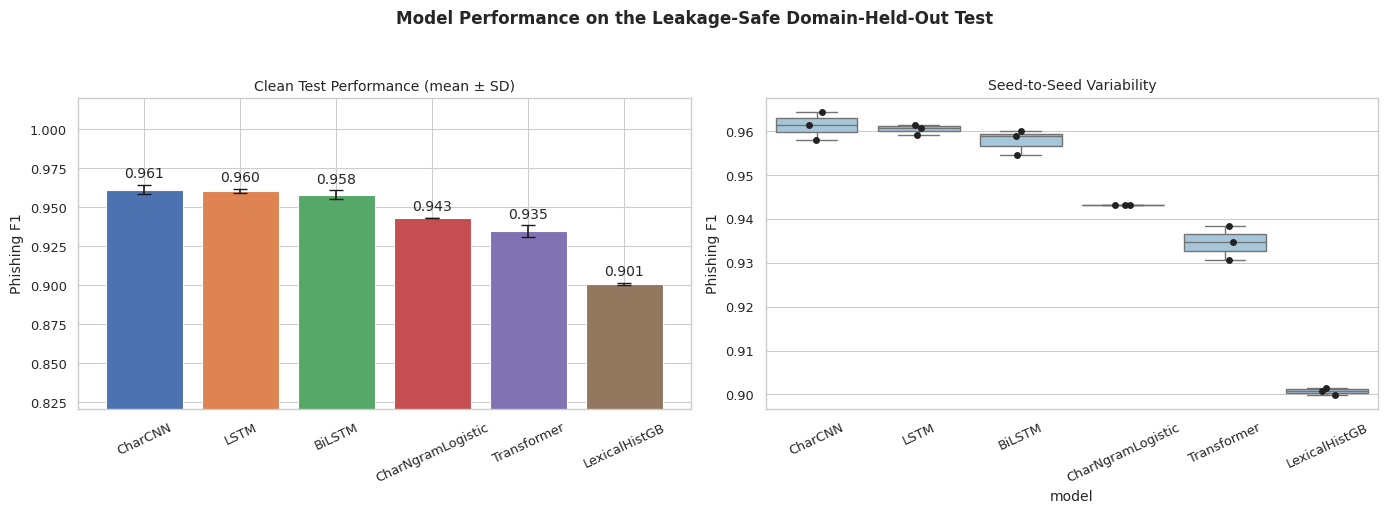

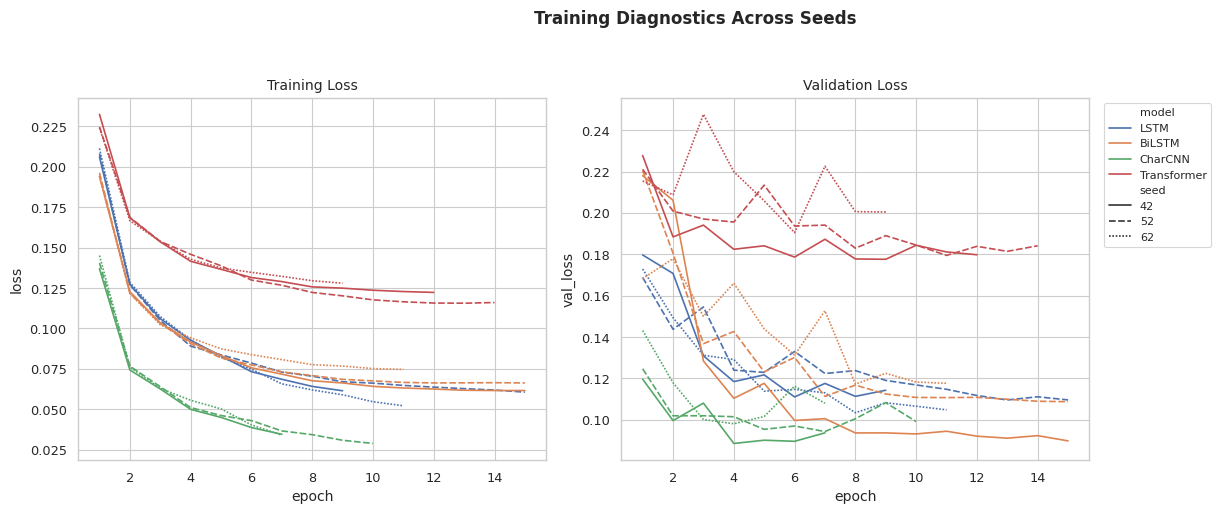

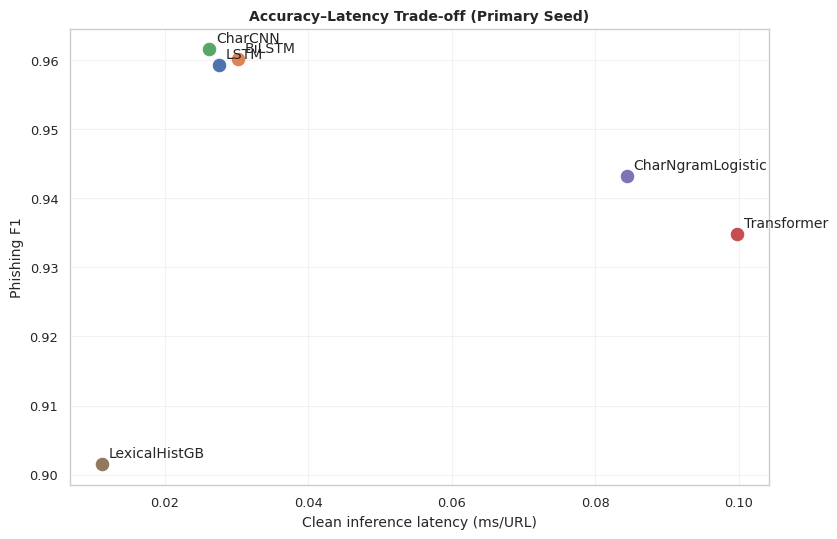

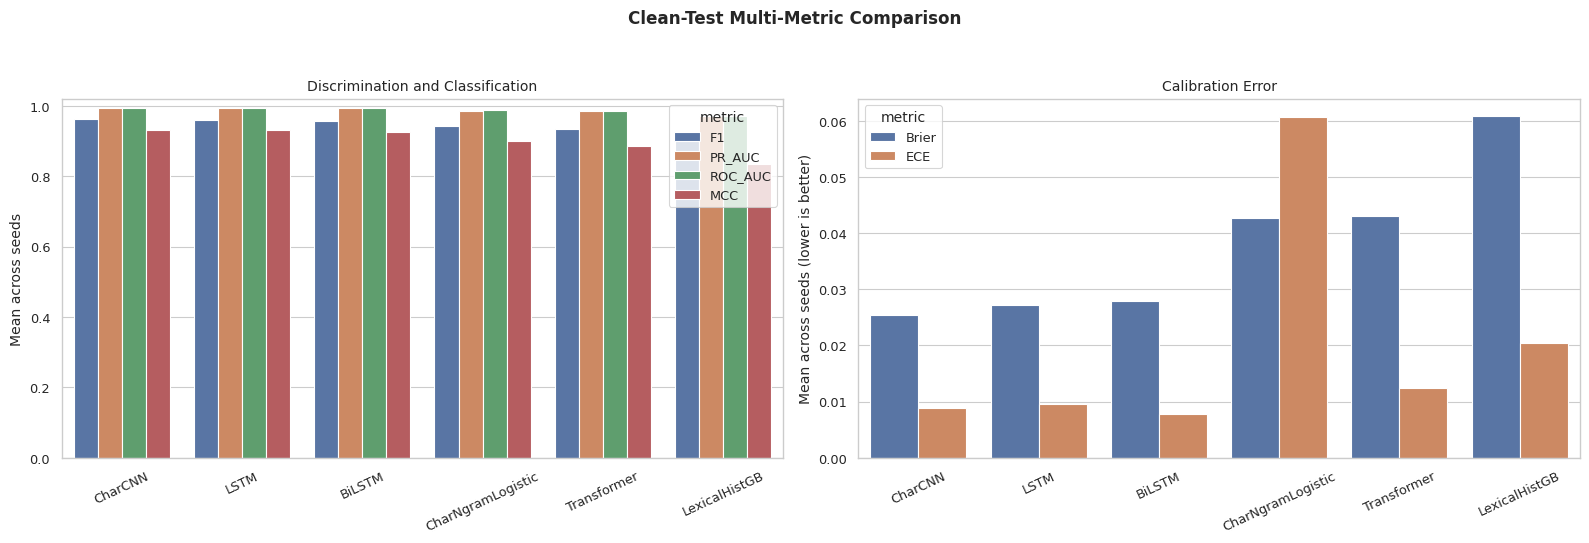

In [20]:
# 18. Model comparison, seed variability, training curves, and efficiency.
FIG_DIR = OUTPUT_DIR / "figures"

clean_seed = metrics_df.query("condition == 'clean' and scope == 'full'").copy()
model_order = clean_seed.groupby("model")["f1"].mean().sort_values(ascending=False).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
clean_summary = clean_seed.groupby("model").agg(f1=("f1", "mean"), sd=("f1", "std")).reindex(model_order)
bars = axes[0].bar(clean_summary.index, clean_summary["f1"], yerr=clean_summary["sd"],
                   capsize=5, color=sns.color_palette("deep", len(clean_summary)))
axes[0].bar_label(bars, fmt="%.3f", padding=3)
axes[0].set_ylim(max(0, clean_summary["f1"].min() - 0.08), 1.02)
axes[0].set_ylabel("Phishing F1")
axes[0].set_title("Clean Test Performance (mean ± SD)")
axes[0].tick_params(axis="x", rotation=25)

sns.boxplot(data=clean_seed, x="model", y="f1", order=model_order, ax=axes[1], color="#9ECAE1")
sns.stripplot(data=clean_seed, x="model", y="f1", order=model_order, ax=axes[1],
              color="#222222", size=5, jitter=0.08)
axes[1].set_ylabel("Phishing F1")
axes[1].set_title("Seed-to-Seed Variability")
axes[1].tick_params(axis="x", rotation=25)
fig.suptitle("Model Performance on the Leakage-Safe Domain-Held-Out Test", fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(FIG_DIR / "FIG02_Clean_Performance_Seeds.png", dpi=300, bbox_inches="tight")
plt.show()

if not history_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
    sns.lineplot(data=history_df, x="epoch", y="loss", hue="model", style="seed", ax=axes[0], legend=False)
    sns.lineplot(data=history_df, x="epoch", y="val_loss", hue="model", style="seed", ax=axes[1])
    axes[0].set_title("Training Loss")
    axes[1].set_title("Validation Loss")
    axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    fig.suptitle("Training Diagnostics Across Seeds", fontweight="bold")
    fig.tight_layout(rect=[0, 0, 0.88, 0.94])
    fig.savefig(FIG_DIR / "FIG03_Training_Curves.png", dpi=300, bbox_inches="tight")
    plt.show()

primary_runs = runs_df[runs_df["seed"] == PRIMARY_SEED].copy()
fig, ax = plt.subplots(figsize=(8.5, 5.5))
primary_clean = clean_seed[clean_seed["seed"] == PRIMARY_SEED][["model", "f1"]]
efficiency = primary_runs.merge(primary_clean, on="model", how="left")
for _, row in efficiency.iterrows():
    ax.scatter(row["clean_inference_ms_per_url"], row["f1"], s=80)
    ax.annotate(row["model"], (row["clean_inference_ms_per_url"], row["f1"]),
                xytext=(5, 5), textcoords="offset points")
ax.set_xlabel("Clean inference latency (ms/URL)")
ax.set_ylabel("Phishing F1")
ax.set_title("Accuracy–Latency Trade-off (Primary Seed)", fontweight="bold")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "FIG04_Performance_Latency.png", dpi=300, bbox_inches="tight")
plt.show()

multi_metric = (
    clean_seed.groupby("model", observed=True)
    .agg(
        F1=("f1", "mean"),
        PR_AUC=("pr_auc", "mean"),
        ROC_AUC=("roc_auc", "mean"),
        MCC=("mcc", "mean"),
        Brier=("brier", "mean"),
        ECE=("ece_15", "mean"),
    )
    .reindex(model_order)
    .reset_index()
)
quality_long = multi_metric.melt(
    id_vars="model",
    value_vars=["F1", "PR_AUC", "ROC_AUC", "MCC"],
    var_name="metric",
    value_name="value",
)
calibration_long = multi_metric.melt(
    id_vars="model",
    value_vars=["Brier", "ECE"],
    var_name="metric",
    value_name="value",
)
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
sns.barplot(
    data=quality_long, x="model", y="value", hue="metric",
    order=model_order, ax=axes[0]
)
axes[0].set_ylim(0, 1.02)
axes[0].set_ylabel("Mean across seeds")
axes[0].set_xlabel("")
axes[0].set_title("Discrimination and Classification")
axes[0].tick_params(axis="x", rotation=25)
sns.barplot(
    data=calibration_long, x="model", y="value", hue="metric",
    order=model_order, ax=axes[1]
)
axes[1].set_ylabel("Mean across seeds (lower is better)")
axes[1].set_xlabel("")
axes[1].set_title("Calibration Error")
axes[1].tick_params(axis="x", rotation=25)
fig.suptitle("Clean-Test Multi-Metric Comparison", fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(FIG_DIR / "FIG04B_Multi_Metric_Comparison.png", dpi=300, bbox_inches="tight")
plt.show()


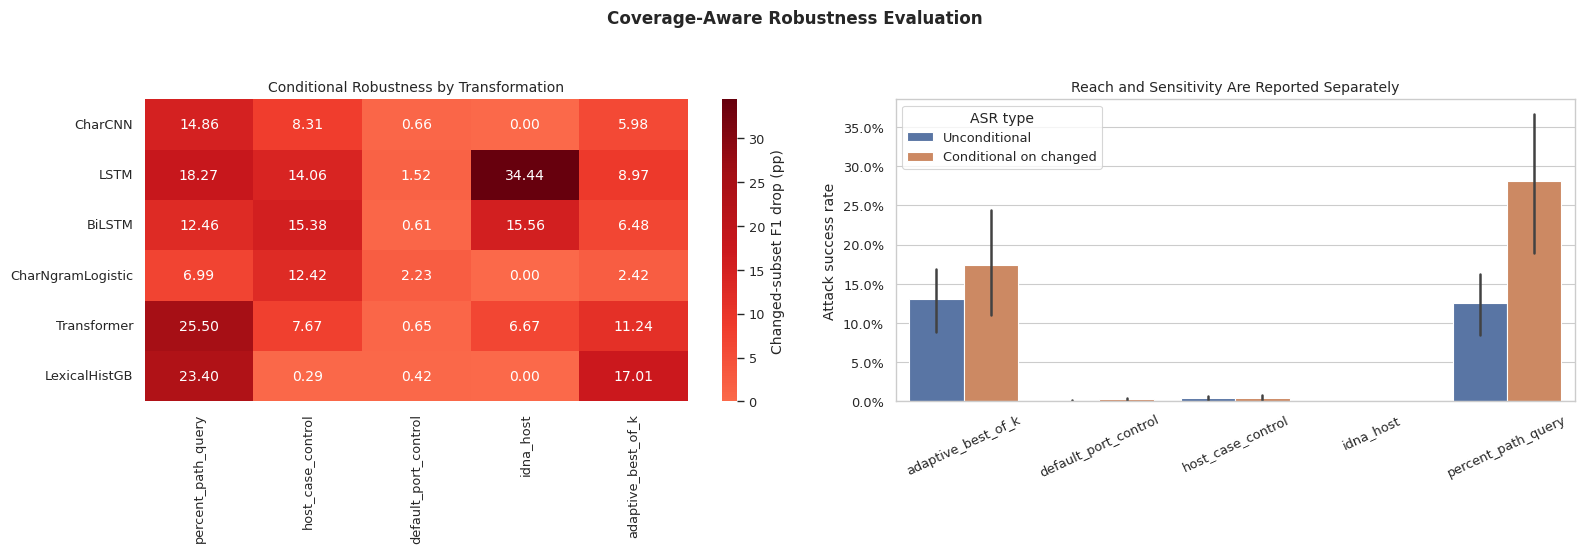

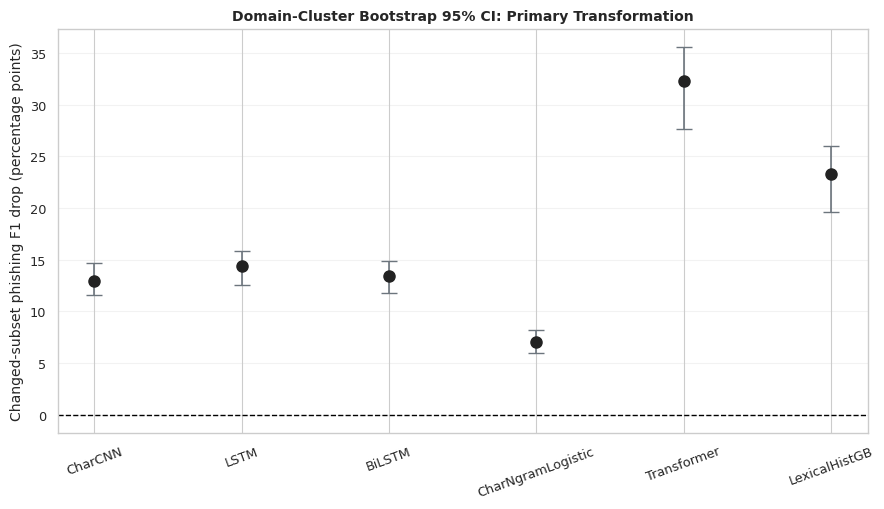

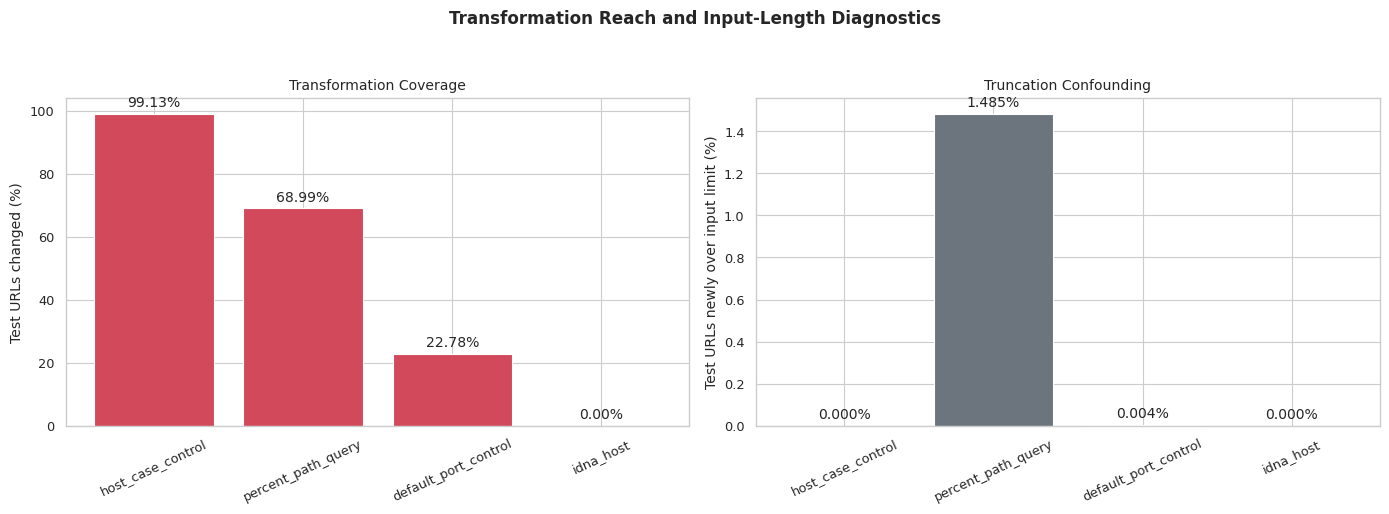

In [21]:
# 19. Coverage-aware robustness, uncertainty, ASR, and transformation diagnostics.
conditions_order = list(TRANSFORMATIONS) + (["adaptive_best_of_k"] if RUN_ADAPTIVE_EVALUATION else [])
summary_plot = robustness_summary[robustness_summary["condition"].isin(conditions_order)].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5.6))
heat = summary_plot.pivot(index="model", columns="condition", values="changed_f1_drop_mean")
heat = heat.reindex(index=model_order, columns=[c for c in conditions_order if c in heat.columns])
sns.heatmap(100 * heat, annot=True, fmt=".2f", cmap="Reds", center=0,
            cbar_kws={"label": "Changed-subset F1 drop (pp)"}, ax=axes[0])
axes[0].set_title("Conditional Robustness by Transformation")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

asr_long = summary_plot.melt(
    id_vars=["model", "condition"],
    value_vars=["asr_unconditional_mean", "asr_conditional_mean"],
    var_name="ASR type", value_name="ASR",
)
asr_long["ASR type"] = asr_long["ASR type"].map({
    "asr_unconditional_mean": "Unconditional",
    "asr_conditional_mean": "Conditional on changed",
})
sns.barplot(data=asr_long, x="condition", y="ASR", hue="ASR type", ax=axes[1])
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{100*y:.1f}%"))
axes[1].set_ylabel("Attack success rate")
axes[1].set_xlabel("")
axes[1].set_title("Reach and Sensitivity Are Reported Separately")
axes[1].tick_params(axis="x", rotation=25)
fig.suptitle("Coverage-Aware Robustness Evaluation", fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(FIG_DIR / "FIG05_Robustness_Heatmap_ASR.png", dpi=300, bbox_inches="tight")
plt.show()

if not statistics_df.empty:
    primary_condition = "percent_path_query"
    ci_plot = statistics_df[statistics_df["condition"] == primary_condition].set_index("model").reindex(model_order).dropna()
    mean_pp = 100 * ci_plot["cluster_bootstrap_mean_f1_drop"]
    low_pp = 100 * ci_plot["cluster_bootstrap_ci_low"]
    high_pp = 100 * ci_plot["cluster_bootstrap_ci_high"]
    errors = np.vstack([mean_pp - low_pp, high_pp - mean_pp])
    fig, ax = plt.subplots(figsize=(9, 5.2))
    ax.errorbar(np.arange(len(ci_plot)), mean_pp, yerr=errors, fmt="o", markersize=8,
                capsize=6, color="#222222", ecolor="#6C757D")
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_xticks(np.arange(len(ci_plot)), ci_plot.index, rotation=20)
    ax.set_ylabel("Changed-subset phishing F1 drop (percentage points)")
    ax.set_title("Domain-Cluster Bootstrap 95% CI: Primary Transformation", fontweight="bold")
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "FIG06_Cluster_Bootstrap_F1_Drop.png", dpi=300, bbox_inches="tight")
    plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
audit_plot = transform_audit_df.sort_values("coverage", ascending=False)
bars = axes[0].bar(audit_plot["condition"], 100 * audit_plot["coverage"], color="#D1495B")
axes[0].bar_label(bars, fmt="%.2f%%", padding=3)
axes[0].set_ylabel("Test URLs changed (%)")
axes[0].set_title("Transformation Coverage")
axes[0].tick_params(axis="x", rotation=25)

trunc = audit_plot[["condition", "newly_over_limit"]].copy()
trunc["share"] = 100 * trunc["newly_over_limit"] / len(test_df)
bars = axes[1].bar(trunc["condition"], trunc["share"], color="#6C757D")
axes[1].bar_label(bars, fmt="%.3f%%", padding=3)
axes[1].set_ylabel("Test URLs newly over input limit (%)")
axes[1].set_title("Truncation Confounding")
axes[1].tick_params(axis="x", rotation=25)
fig.suptitle("Transformation Reach and Input-Length Diagnostics", fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(FIG_DIR / "FIG07_Transformation_Coverage_Truncation.png", dpi=300, bbox_inches="tight")
plt.show()


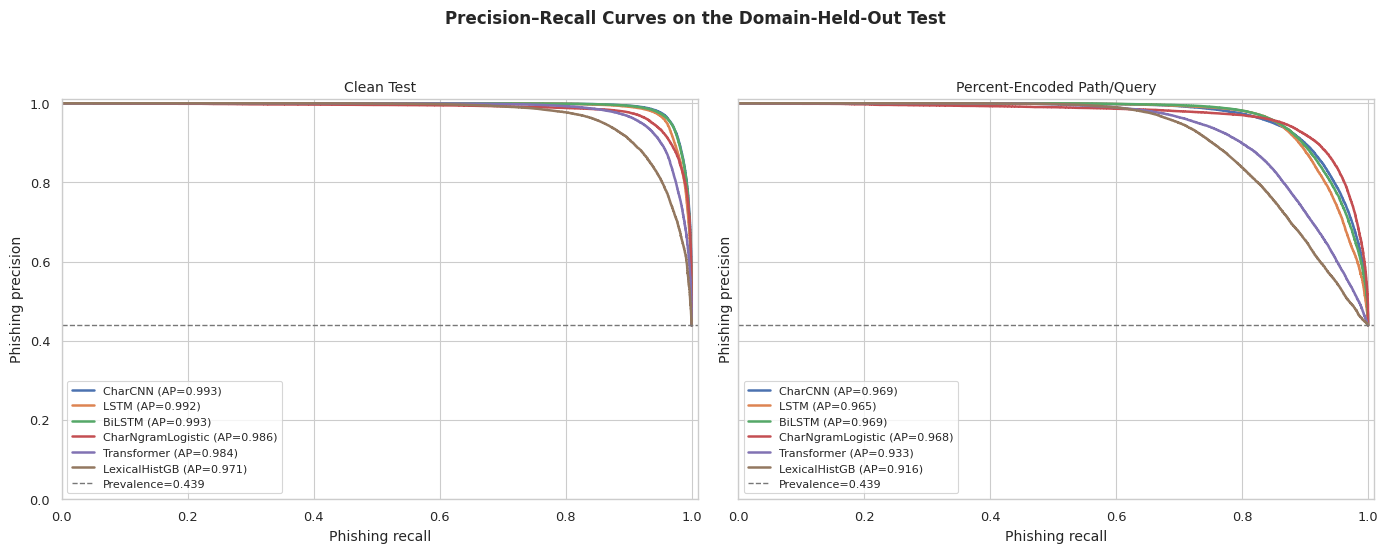

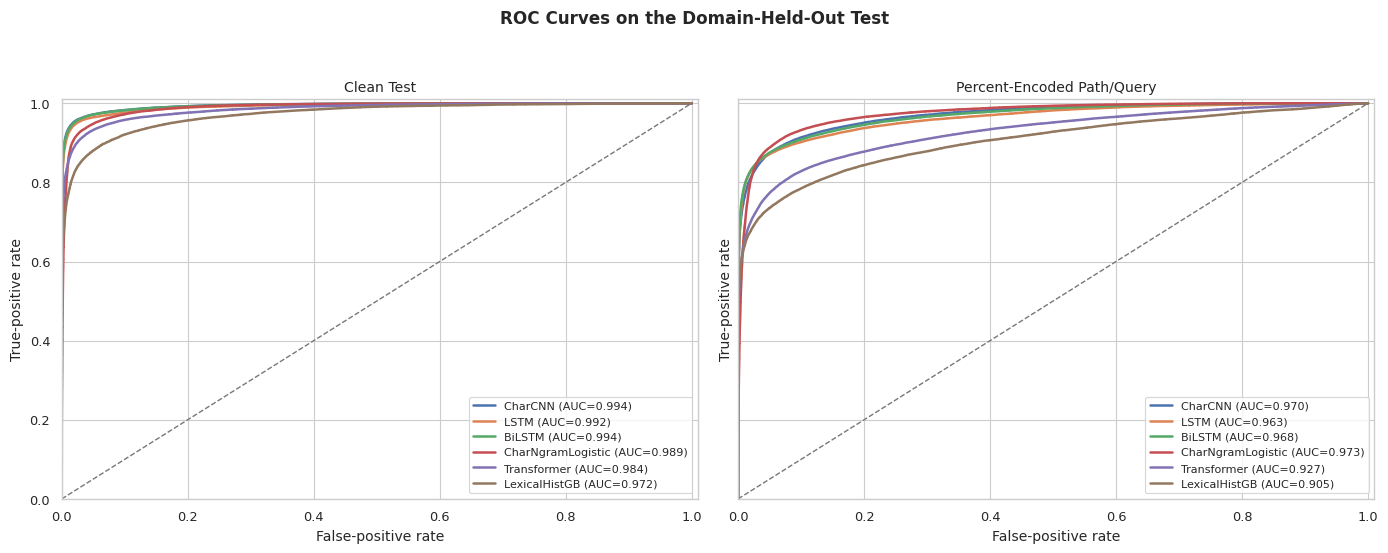

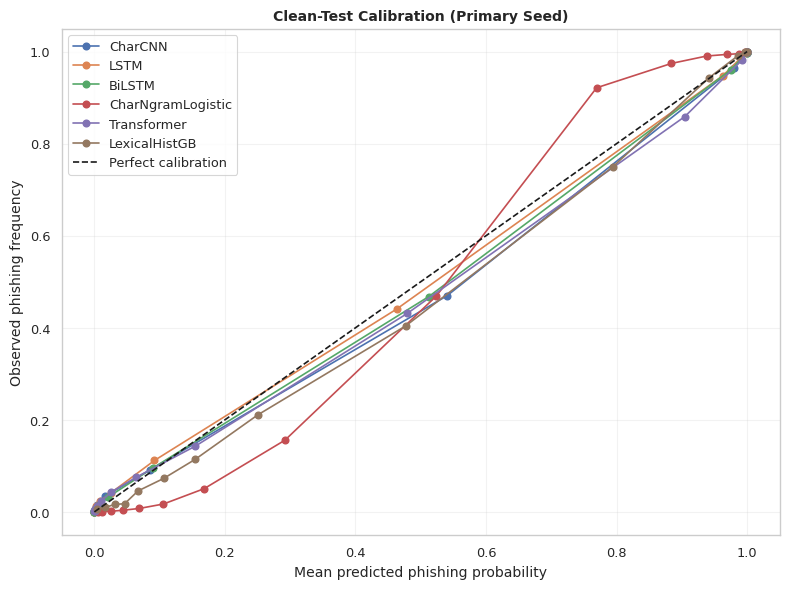

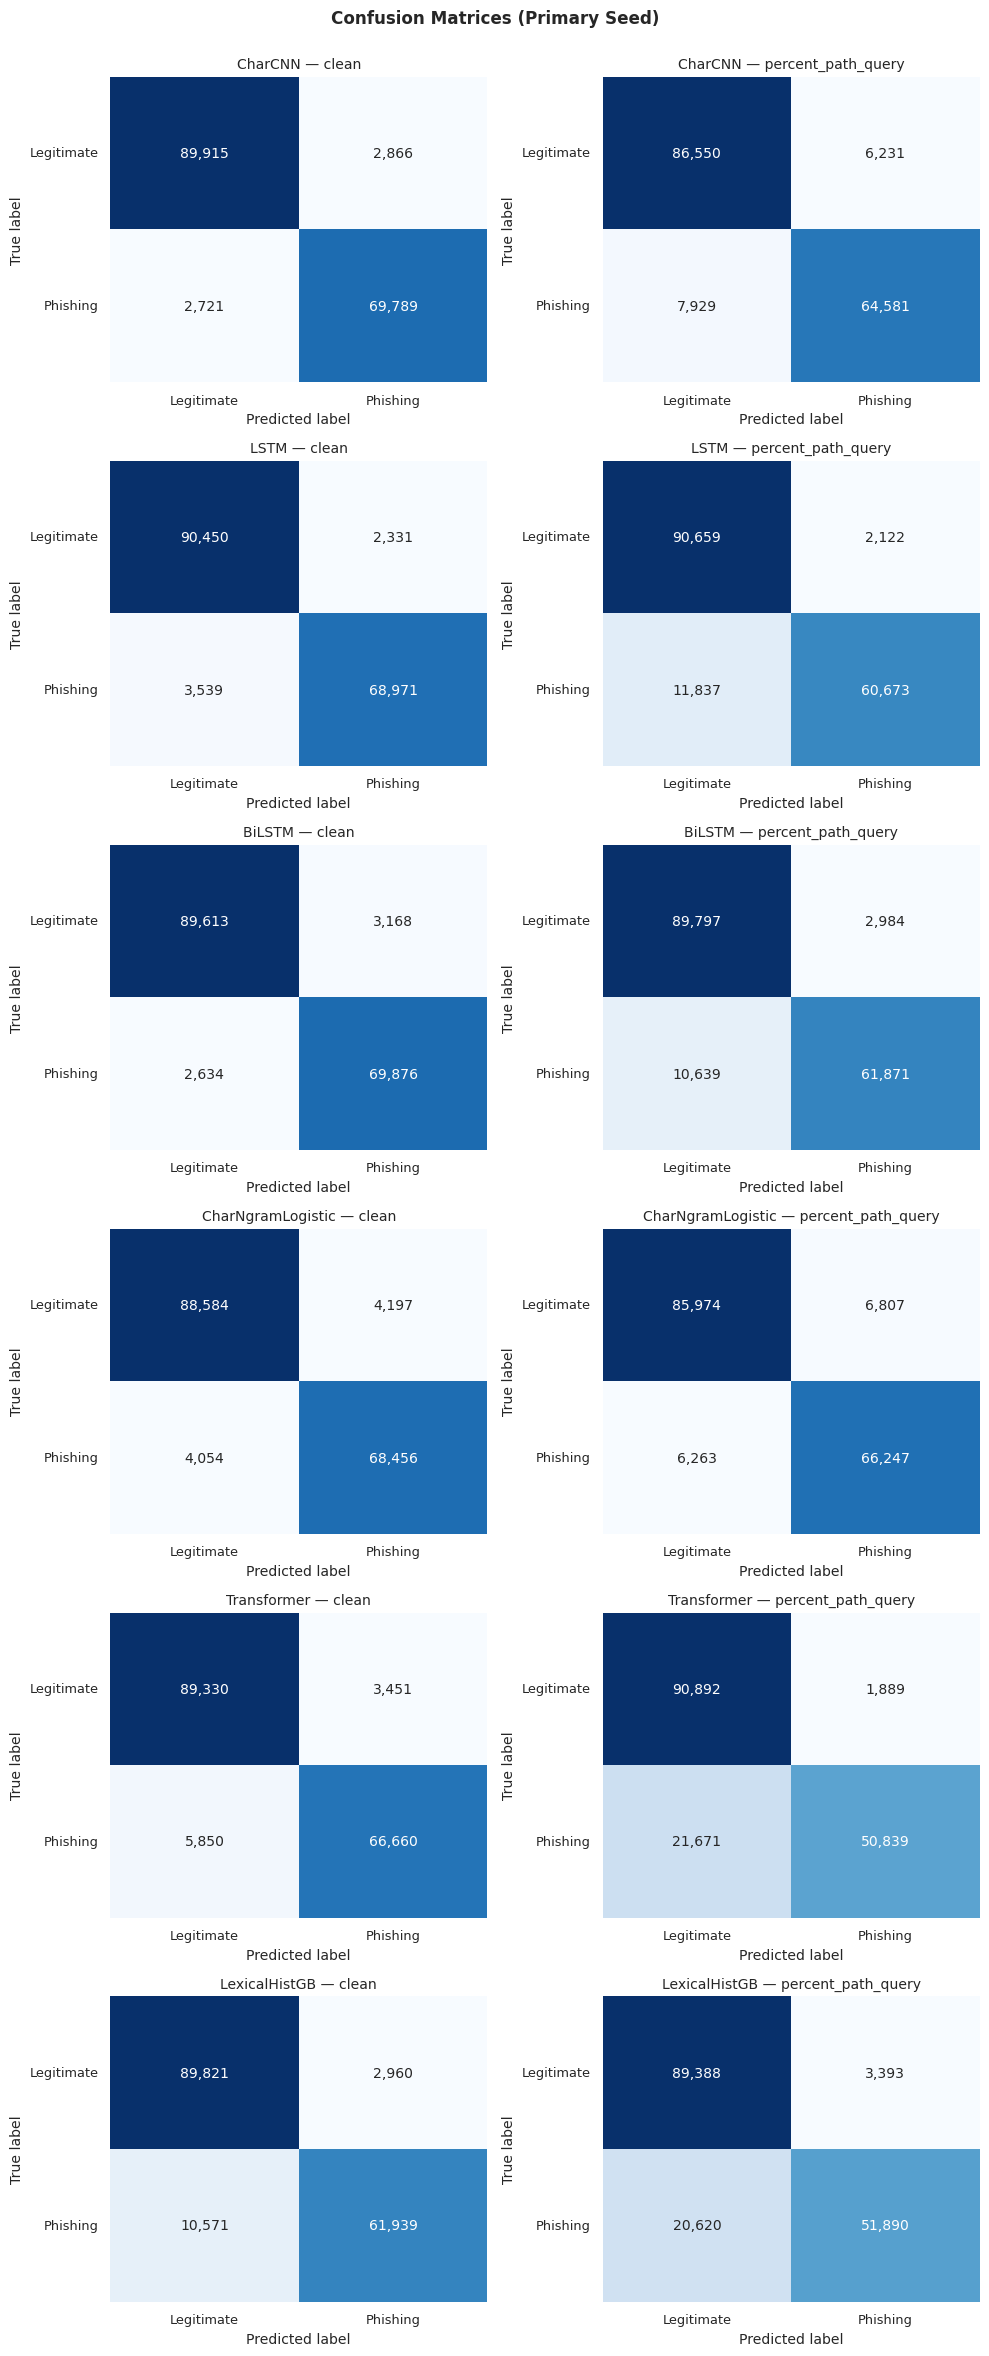

In [22]:
# 20. Precision-recall, calibration, and confusion-matrix figures (primary seed).
primary_models = [m for m in model_order if (m, "clean") in curve_store]
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6), sharex=True, sharey=True)
for ax, condition, title in [
    (axes[0], "clean", "Clean Test"),
    (axes[1], "percent_path_query", "Percent-Encoded Path/Query"),
]:
    for model_name in primary_models:
        probability = curve_store.get((model_name, condition))
        if probability is None:
            continue
        precision, recall, _ = precision_recall_curve(y_test, probability)
        ap = average_precision_score(y_test, probability)
        ax.plot(recall, precision, linewidth=1.8, label=f"{model_name} (AP={ap:.3f})")
    ax.axhline(y_test.mean(), color="#777777", linestyle="--", linewidth=1,
               label=f"Prevalence={y_test.mean():.3f}")
    ax.set_xlabel("Phishing recall")
    ax.set_ylabel("Phishing precision")
    ax.set_title(title)
    ax.set_xlim(0, 1.01)
    ax.set_ylim(0, 1.01)
    ax.legend(loc="lower left", fontsize=8)
fig.suptitle("Precision–Recall Curves on the Domain-Held-Out Test", fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(FIG_DIR / "FIG08_Precision_Recall_Curves.png", dpi=300, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.6), sharex=True, sharey=True)
for ax, condition, title in [
    (axes[0], "clean", "Clean Test"),
    (axes[1], "percent_path_query", "Percent-Encoded Path/Query"),
]:
    for model_name in primary_models:
        probability = curve_store.get((model_name, condition))
        if probability is None:
            continue
        false_positive_rate, true_positive_rate, _ = roc_curve(y_test, probability)
        auc = roc_auc_score(y_test, probability)
        ax.plot(
            false_positive_rate,
            true_positive_rate,
            linewidth=1.8,
            label=f"{model_name} (AUC={auc:.3f})",
        )
    ax.plot([0, 1], [0, 1], color="#777777", linestyle="--", linewidth=1)
    ax.set_xlabel("False-positive rate")
    ax.set_ylabel("True-positive rate")
    ax.set_title(title)
    ax.set_xlim(0, 1.01)
    ax.set_ylim(0, 1.01)
    ax.legend(loc="lower right", fontsize=8)
fig.suptitle("ROC Curves on the Domain-Held-Out Test", fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(FIG_DIR / "FIG09_ROC_Curves.png", dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
for model_name in primary_models:
    probability = curve_store[(model_name, "clean")]
    observed, predicted = calibration_curve(y_test, probability, n_bins=15, strategy="quantile")
    ax.plot(predicted, observed, marker="o", label=model_name)
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.set_xlabel("Mean predicted phishing probability")
ax.set_ylabel("Observed phishing frequency")
ax.set_title("Clean-Test Calibration (Primary Seed)", fontweight="bold")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "FIG10_Calibration.png", dpi=300, bbox_inches="tight")
plt.show()

n_models = len(primary_models)
fig, axes = plt.subplots(n_models, 2, figsize=(10, 4 * n_models), squeeze=False)
threshold_map = runs_df[runs_df["seed"] == PRIMARY_SEED].set_index("model")["threshold"].to_dict()
for row, model_name in enumerate(primary_models):
    threshold = threshold_map[model_name]
    for col, condition in enumerate(["clean", "percent_path_query"]):
        probability = curve_store[(model_name, condition)]
        prediction = (probability >= threshold).astype(np.int8)
        cm = confusion_matrix(y_test, prediction, labels=[0, 1])
        sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=axes[row, col])
        axes[row, col].set_title(f"{model_name} — {condition}")
        axes[row, col].set_xlabel("Predicted label")
        axes[row, col].set_ylabel("True label")
        axes[row, col].set_xticklabels(["Legitimate", "Phishing"])
        axes[row, col].set_yticklabels(["Legitimate", "Phishing"], rotation=0)
fig.suptitle("Confusion Matrices (Primary Seed)", fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.98])
fig.savefig(FIG_DIR / "FIG11_Confusion_Matrices.png", dpi=300, bbox_inches="tight")
plt.show()


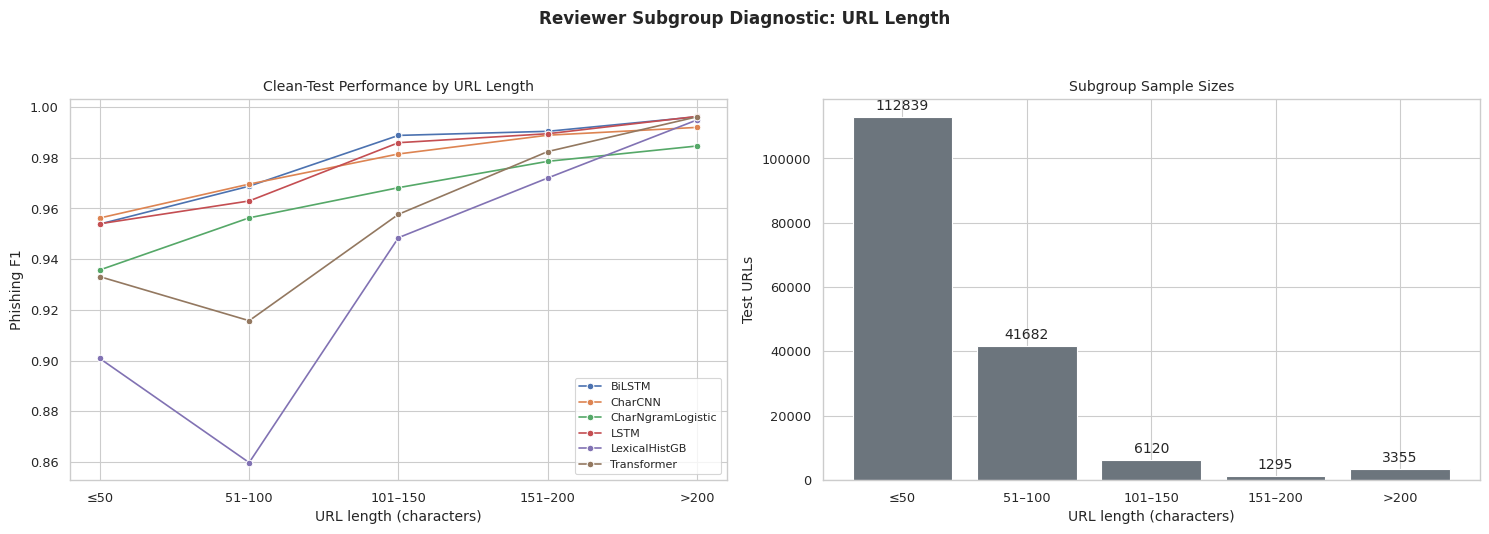

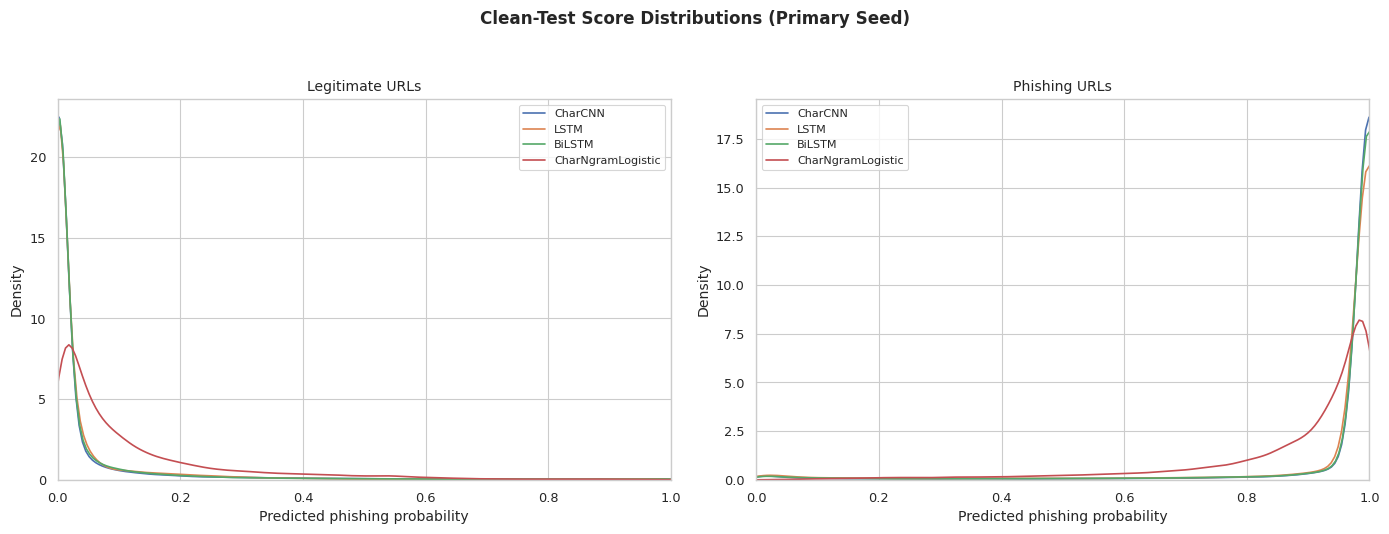

In [23]:
# 20b. URL-length subgroup performance and clean-score distributions.
if not subgroup_df.empty:
    length_order = ["≤50", "51–100", "101–150", "151–200", ">200"]
    length_plot = subgroup_df[subgroup_df["analysis"] == "url_length"].copy()
    length_plot["subgroup"] = pd.Categorical(
        length_plot["subgroup"], categories=length_order, ordered=True
    )
    length_plot = length_plot.sort_values(["subgroup", "model"])

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.4))
    sns.lineplot(
        data=length_plot,
        x="subgroup",
        y="f1",
        hue="model",
        marker="o",
        estimator=None,
        ax=axes[0],
    )
    axes[0].set_xlabel("URL length (characters)")
    axes[0].set_ylabel("Phishing F1")
    axes[0].set_title("Clean-Test Performance by URL Length")
    axes[0].legend(fontsize=8)

    count_frame = (
        length_plot.drop_duplicates("subgroup")
        .set_index("subgroup")
        .reindex(length_order)
        .dropna(subset=["rows"])
    )
    bars = axes[1].bar(
        count_frame.index.astype(str), count_frame["rows"], color="#6C757D"
    )
    axes[1].bar_label(bars, fmt="%d", padding=3)
    axes[1].set_xlabel("URL length (characters)")
    axes[1].set_ylabel("Test URLs")
    axes[1].set_title("Subgroup Sample Sizes")
    fig.suptitle("Reviewer Subgroup Diagnostic: URL Length", fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    fig.savefig(FIG_DIR / "FIG12_URL_Length_Subgroups.png", dpi=300, bbox_inches="tight")
    plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
score_models = primary_models[: min(4, len(primary_models))]
for ax, label, title in [
    (axes[0], 0, "Legitimate URLs"),
    (axes[1], 1, "Phishing URLs"),
]:
    for model_name in score_models:
        probability = curve_store[(model_name, "clean")]
        sns.kdeplot(
            probability[y_test == label],
            ax=ax,
            label=model_name,
            fill=False,
            common_norm=False,
        )
    ax.set_xlim(0, 1)
    ax.set_xlabel("Predicted phishing probability")
    ax.set_ylabel("Density")
    ax.set_title(title)
    ax.legend(fontsize=8)
fig.suptitle("Clean-Test Score Distributions (Primary Seed)", fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(FIG_DIR / "FIG13_Score_Distributions.png", dpi=300, bbox_inches="tight")
plt.show()


In [24]:
# 21. Reproducibility bundle and automated reviewer checklist.
(OUTPUT_DIR / "CONFIG.json").write_text(
    json.dumps({
        **CONFIG,
        "versions": VERSIONS,
        "dataset_path": str(dataset_path),
        "dataset_sha256": dataset_sha256,
    }, indent=2),
    encoding="utf-8",
)
try:
    freeze = subprocess.check_output([sys.executable, "-m", "pip", "freeze"], text=True)
    (OUTPUT_DIR / "requirements_frozen.txt").write_text(freeze, encoding="utf-8")
except Exception as exc:
    print("Could not freeze environment:", exc)

leakage_checks = {
    "canonical_url_hash_unique_after_cleaning": bool(clean_df["url_hash"].is_unique),
    "train_validation_domain_overlap": len(
        set(train_df["domain_group"]) & set(val_df["domain_group"])
    ),
    "train_test_domain_overlap": len(
        set(train_df["domain_group"]) & set(test_df["domain_group"])
    ),
    "validation_test_domain_overlap": len(
        set(val_df["domain_group"]) & set(test_df["domain_group"])
    ),
    "vocabulary_fit_on_training_only": True,
    "threshold_selected_on_validation_only": True,
    "test_used_for_checkpoint_selection": False,
    "paired_predictions_exported": True,
    "conditional_asr_reported": True,
    "cluster_aware_uncertainty_reported": True,
    "multi_seed_results_reported": len(SEEDS) > 1,
    "classical_and_neural_baselines_included": RUN_CLASSICAL_BASELINES and "CharCNN" in MODEL_FACTORIES,
    "pairwise_clean_model_tests_reported": not pairwise_models_df.empty,
    "subgroup_diagnostics_reported": not subgroup_df.empty,
}

expected_models = []
if RUN_DEEP_MODELS:
    expected_models.extend(MODEL_FACTORIES)
if RUN_CLASSICAL_BASELINES:
    expected_models.extend(["CharNgramLogistic", "LexicalHistGB"])
expected_run_keys = {
    (model_name, int(seed)) for model_name in expected_models for seed in SEEDS
}
observed_run_keys = {
    (str(row["model"]), int(row["seed"])) for row in run_rows
}
missing_run_keys = sorted(expected_run_keys - observed_run_keys)
unexpected_run_keys = sorted(observed_run_keys - expected_run_keys)
leakage_checks["all_expected_runs_completed"] = len(missing_run_keys) == 0
leakage_checks["no_unexpected_runs"] = len(unexpected_run_keys) == 0

prediction_files = sorted((OUTPUT_DIR / "predictions").glob("PAIRED_PREDICTIONS_*"))
done_markers = sorted((OUTPUT_DIR / "runs").glob("*/DONE.json"))
leakage_checks["one_prediction_file_per_run"] = len(prediction_files) == len(expected_run_keys)
leakage_checks["one_done_marker_per_run"] = len(done_markers) == len(expected_run_keys)
(OUTPUT_DIR / "REVIEWER_CHECKLIST.json").write_text(
    json.dumps(leakage_checks, indent=2), encoding="utf-8"
)
assert all(value is True or value == 0 for value in leakage_checks.values())

completeness_df = pd.DataFrame([
    {
        "model": model_name,
        "seed": seed,
        "completed": (model_name, seed) in observed_run_keys,
        "done_marker": (_run_directory(model_name, seed) / "DONE.json").exists(),
    }
    for model_name, seed in sorted(expected_run_keys)
])
completeness_df.to_csv(
    OUTPUT_DIR / "tables" / "RUN_COMPLETENESS.csv", index=False
)

def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        while True:
            chunk = handle.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()

manifest_rows = []
for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file():
        manifest_rows.append({
            "relative_path": str(path.relative_to(OUTPUT_DIR)),
            "bytes": int(path.stat().st_size),
            "sha256": sha256_file(path),
        })
manifest_df = pd.DataFrame(manifest_rows)
manifest_df.to_csv(OUTPUT_DIR / "FILE_MANIFEST_SHA256.csv", index=False)

readme_text = f"""# Phishing URL robustness experiment outputs

Completed model/seed runs: {len(observed_run_keys)} / {len(expected_run_keys)}
Missing runs: {missing_run_keys}

Important directories:
- tables/: exact numerical results and statistical tests
- figures/: publication-ready 300 DPI figures
- predictions/: paired per-example probabilities, predictions, and changed masks
- models/: deep checkpoints and fitted classical estimators
- runs/: crash-safe per-run records; DONE.json is written last

Primary inference uses seed {PRIMARY_SEED}; other seeds quantify variability.
Thresholds were selected on validation data only. The test set is domain-held-out.
"""
(OUTPUT_DIR / "RESULTS_README.md").write_text(readme_text, encoding="utf-8")

print("\nReviewer checklist:")
print(json.dumps(leakage_checks, indent=2))
print("\nSaved outputs:")
for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file():
        print(" -", path.relative_to(OUTPUT_DIR))

if CREATE_FINAL_ZIP:
    archive_base = OUTPUT_DIR.parent / "phishing_robustness_v3_complete"
    archive_path = shutil.make_archive(
        str(archive_base), "zip", root_dir=OUTPUT_DIR
    )
    print("\nFINAL BACKUP:", archive_path)
    print("Archive size (MB):", round(Path(archive_path).stat().st_size / (1024 ** 2), 2))
    print(
        "Download this ZIP immediately or use Kaggle Save Version with outputs. "
        "A new Kaggle session does not preserve uncommitted /kaggle/working files."
    )



Reviewer checklist:
{
  "canonical_url_hash_unique_after_cleaning": true,
  "train_validation_domain_overlap": 0,
  "train_test_domain_overlap": 0,
  "validation_test_domain_overlap": 0,
  "vocabulary_fit_on_training_only": true,
  "threshold_selected_on_validation_only": true,
  "test_used_for_checkpoint_selection": false,
  "paired_predictions_exported": true,
  "conditional_asr_reported": true,
  "cluster_aware_uncertainty_reported": true,
  "multi_seed_results_reported": true,
  "classical_and_neural_baselines_included": true,
  "pairwise_clean_model_tests_reported": true,
  "subgroup_diagnostics_reported": true,
  "all_expected_runs_completed": true,
  "no_unexpected_runs": true,
  "one_prediction_file_per_run": true,
  "one_done_marker_per_run": true
}

Saved outputs:
 - CONFIG.json
 - FILE_MANIFEST_SHA256.csv
 - RESULTS_README.md
 - REVIEWER_CHECKLIST.json
 - character_vocabulary.json
 - figures/FIG00_Cleaning_Audit.png
 - figures/FIG01_Split_Diagnostics.png
 - figures/FIG02_Cl